1. Check Duplicate Datetime Values  
2. Check missing Date-Time values → Check time difference
3. Boxplot
4. Lowest anomaly demand – 487 MW on 29-May-2003
5. Handling Lowest value – Clean dataset creation
6. Low Demand Analysis (<2890 MW)
7. High Demand Analysis
8. Upper bound capping decision – Why 9000 MW?
9. Autocorrelation Analysis → Lag 1, 24 and 16 hours
10. Yearly Analysis → 2013 vs 2014 → Check Trend and Seasonality
11. Business Hypothesis
    Population ↑ + Migration ↑ + Industrial Activity ↑ → Electricity Demand ↑
12. Seasonal, Monthly, Weekly & Hourly Analysis
13. Holiday Analysis
14. Rolling Mean And Rolling Standard Deviation → Check data is stationary
15. Overall Findings


In [95]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [96]:
# LOAD DATASET

df = pd.read_excel('PJMW_MW_Hourly.xlsx')

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [97]:
# CREATE RAW BACKUP

df_raw = df.copy()

print("Raw dataset backup created.")

Raw dataset backup created.


df_raw

In [98]:
# DATASET SHAPE

rows, columns = df.shape

print("Number of rows    :", rows)
print("Number of columns :", columns)

Number of rows    : 143206
Number of columns : 2


In [99]:
# DESCRIPTIVE STATISTICS

display(df["PJMW_MW"].describe())

count    143206.000000
mean       5602.375089
std         979.142872
min         487.000000
25%        4907.000000
50%        5530.000000
75%        6252.000000
max        9594.000000
Name: PJMW_MW, dtype: float64

### Dataset Information and Datype conversion 

In [100]:
# DATASET INFORMATION

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  143206 non-null  datetime64[ns]
 1   PJMW_MW   143206 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.2 MB


In [101]:
# CONVERT DATETIME to datatype - Datetime

df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

print(df.dtypes)

Datetime    datetime64[ns]
PJMW_MW              int64
dtype: object


errors="coerce" => it wil convert INVALID_DATE => Convert this to datetime, and if something cannot be converted, don't crash—turn it into NaT.

NaT means Not a Time, similar to how NaN represents a missing numerical value.

___

### CHECK DUPLICATE DATETIME VALUES

In [102]:
# CHECK DUPLICATE DATETIME VALUES

duplicate_datetime_count = df["Datetime"].duplicated().sum()

print("Duplicate timestamps:", duplicate_datetime_count)

Duplicate timestamps: 4


In [103]:
duplicate_datetime_rows = df[
    df["Datetime"].duplicated(keep=False)
].sort_values("Datetime")

display(duplicate_datetime_rows)

,Datetime,PJMW_MW
104424,2014-11-02 02:00:00,4613
104425,2014-11-02 02:00:00,4571
113208,2015-11-01 02:00:00,3927
113209,2015-11-01 02:00:00,3832
121848,2016-11-06 02:00:00,4114
121849,2016-11-06 02:00:00,4089
130656,2017-11-05 02:00:00,4042
130657,2017-11-05 02:00:00,3984


## Duplicate Timestamp Analysis

- These repeated timestamps occur around **U.S. Daylight Saving Time (DST) transitions**.
- During DST, the clock moves back by one hour, so a local time can occur twice.
- All identified duplicate timestamps occur in **November**, which is consistent with the U.S. transition from Daylight Saving Time back to standard time.


01:00 \
02:00 \
02:00  ← repeated local hour\
03:00


* These are **not exact duplicate rows** because the `PJMW_MW` values are different.
* Therefore, these rows should **not be blindly deleted**.

___

### SORT DATA CHRONOLOGICALLY

In [104]:
# SORT DATA CHRONOLOGICALLY

df = df.sort_values("Datetime").reset_index(drop=True)

print("Dataset sorted chronologically.")

Dataset sorted chronologically.


Before sorting 

Datetime	PJMW_MW\
2002-12-31 1:00:00	5077\
2002-12-31 2:00:00	4939\
2002-12-31 3:00:00	4885


After sorting start from 

2002-04-01 1:00:00	4374\
2002-04-01 2:00:00	4306\
2002-04-01 3:00:00	4322
____

### Check missing Date-Time values => Check time difference  

In [105]:
# CHECK TIME DIFFERENCES

df["Time_Difference"] = df["Datetime"].diff()

print(
    df["Time_Difference"]
    .value_counts()
    .head(20)
)

Time_Difference
0 days 01:00:00    143171
0 days 02:00:00        30
0 days 00:00:00         4
Name: count, dtype: int64


- 2 hours -> 30 such enteries 
- 0 hours → 4 => This means there are 4 cases where consecutive rows have exactly the same timestamp. DTS 

Identify places where time difference > 1 hr.

In [106]:
# Find rows where the gap is greater than 1 hour
gap_indices = df.index[
    df["Time_Difference"] > pd.Timedelta(hours=1)
]

# Display the row before and the row where the gap occurs
for idx in gap_indices:
    display(
        df.loc[
            max(0, idx - 1):idx,
            ["Datetime", "PJMW_MW", "Time_Difference"]
        ]
    )

,Datetime,PJMW_MW,Time_Difference
145,2002-04-07 02:00:00,4858,0 days 01:00:00
146,2002-04-07 04:00:00,4871,0 days 02:00:00


,Datetime,PJMW_MW,Time_Difference
5015,2002-10-27 01:00:00,4304,0 days 01:00:00
5016,2002-10-27 03:00:00,4014,0 days 02:00:00


,Datetime,PJMW_MW,Time_Difference
8879,2003-04-06 02:00:00,4365,0 days 01:00:00
8880,2003-04-06 04:00:00,4376,0 days 02:00:00


,Datetime,PJMW_MW,Time_Difference
13749,2003-10-26 01:00:00,4321,0 days 01:00:00
13750,2003-10-26 03:00:00,4027,0 days 02:00:00


,Datetime,PJMW_MW,Time_Difference
17613,2004-04-04 02:00:00,4724,0 days 01:00:00
17614,2004-04-04 04:00:00,4691,0 days 02:00:00


...

,Datetime,PJMW_MW,Time_Difference
104616,2014-03-09 02:00:00,4812,0 days 01:00:00
104617,2014-03-09 04:00:00,4840,0 days 02:00:00


,Datetime,PJMW_MW,Time_Difference
113352,2015-03-08 02:00:00,5412,0 days 01:00:00
113353,2015-03-08 04:00:00,5365,0 days 02:00:00


,Datetime,PJMW_MW,Time_Difference
122256,2016-03-13 02:00:00,3900,0 days 01:00:00
122257,2016-03-13 04:00:00,3790,0 days 02:00:00


,Datetime,PJMW_MW,Time_Difference
130992,2017-03-12 02:00:00,5913,0 days 01:00:00
130993,2017-03-12 04:00:00,5904,0 days 02:00:00


,Datetime,PJMW_MW,Time_Difference
139728,2018-03-11 02:00:00,5533,0 days 01:00:00
139729,2018-03-11 04:00:00,5610,0 days 02:00:00


### Analysis of 2-Hour Time Gaps

- A total of **30 intervals with a 2-hour difference** were identified in the dataset.

- The 2-hour gaps occur consistently around dates such as:
  - March 2007–2018
  - October/November 2002–2013
  - November 2014–2017

- These dates correspond to the **U.S. Daylight Saving Time (DST) transitions**.

- During the **spring DST transition**, the clock moves forward by one hour. Therefore, one local hour is skipped, resulting in a **2-hour difference** between consecutive recorded timestamps.

- During the **autumn DST transition**, the clock moves backward by one hour. This can also affect the recorded local-time sequence.

- The repeated pattern across multiple years indicates that these gaps are **systematic and related to DST**, rather than random missing data.


- There is **one unusual 2-hour gap on `2010-12-10 01:00:00`**, which does not fall around the usual DST transition period. This should be treated separately.

**Not taking any action for this**

### Insert the missing for for the 10-Dec-2010 12 am 

In [168]:
missing_time = pd.Timestamp("2010-12-10 00:00:00")

# Insert the missing timestamp
df.loc[len(df), "Datetime"] = missing_time

# Sort again
df = df.sort_values("Datetime").reset_index(drop=True)

Interpolate the missing demand value

Because 00:00 is between:

23:00 → 6972 MW \
01:00 → 6280 MW

linear interpolation gives:


(6972+6280)/2  = 6626 MW

In [169]:
df["PJMW_MW"] = df["PJMW_MW"].interpolate(method="linear")

Verify using .loc

In [170]:
df.loc[
    df["Datetime"] == "2010-12-10 00:00:00"
]

,Datetime,PJMW_MW,Time_Difference,PJMW_MW_Clean,Possible_Anomaly,Year,Month,Month_Name,Day,DayOfWeek,...,DayOfYear,Season,Is_Weekend,Day_Type,Holiday_Name,Is_Holiday,Rolling_Mean_24,Rolling_Std_24,Rolling_Mean_168,Rolling_Std_168
76181,2010-12-10,6626.0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Verify the surrounding timestamps

In [171]:
df.loc[
    (df["Datetime"] >= "2010-12-09 22:00:00") &
    (df["Datetime"] <= "2010-12-10 02:00:00"),
    ["Datetime", "PJMW_MW"]
]

,Datetime,PJMW_MW
76179,2010-12-09 22:00:00,7354.0
76180,2010-12-09 23:00:00,6972.0
76181,2010-12-10 00:00:00,6626.0
76182,2010-12-10 01:00:00,6280.0
76183,2010-12-10 02:00:00,6117.0


___

## Demand Distribution

Skewness of Power Demand:  0.3348532861122116
Kurtosis of Power Demand:  -0.2214559469116555


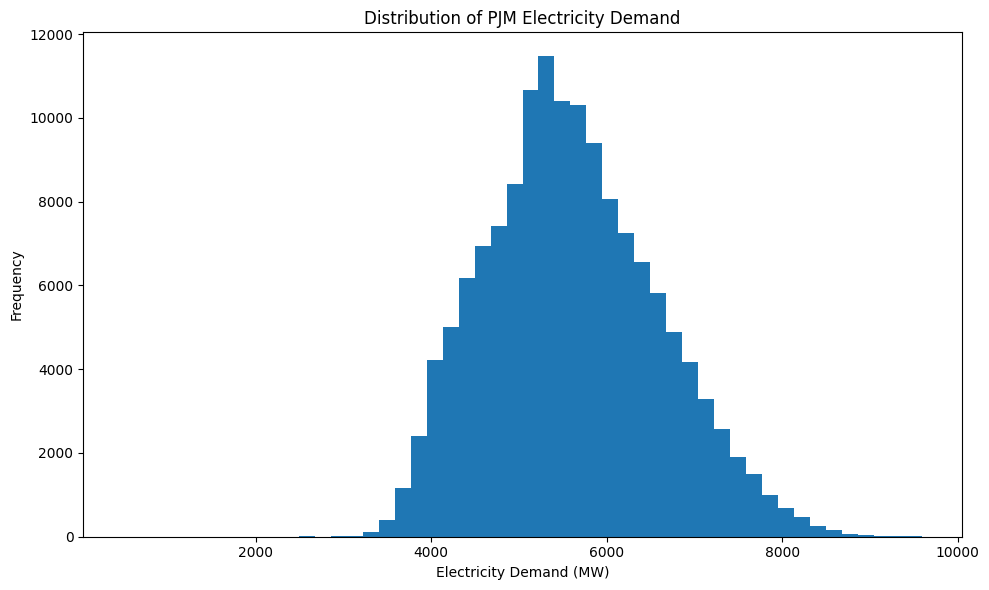

In [107]:
# DEMAND DISTRIBUTION

print('Skewness of Power Demand: ', df["PJMW_MW"].skew())
print('Kurtosis of Power Demand: ', df["PJMW_MW"].kurt())

plt.figure(figsize=(10, 6))

plt.hist(
    df["PJMW_MW"],
    bins=50
)

plt.title(
    "Distribution of PJM Electricity Demand"
)

plt.xlabel("Electricity Demand (MW)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

#### Observation - 
-0.2215 means your PJMW_MW distribution is slightly platykurtic compared with a normal distribution.


The PJMW_MW variable has an excess kurtosis of -0.221, indicating a slightly platykurtic distribution. This suggests that the distribution has somewhat lighter tails and fewer extreme observations compared with a normal distribution. However, the value is close to zero, so the deviation from a normal distribution is relatively small.


Overall => 

**Relatively close to a symmetric/normal-like distribution, but not exactly normal**

____

## Boxplot

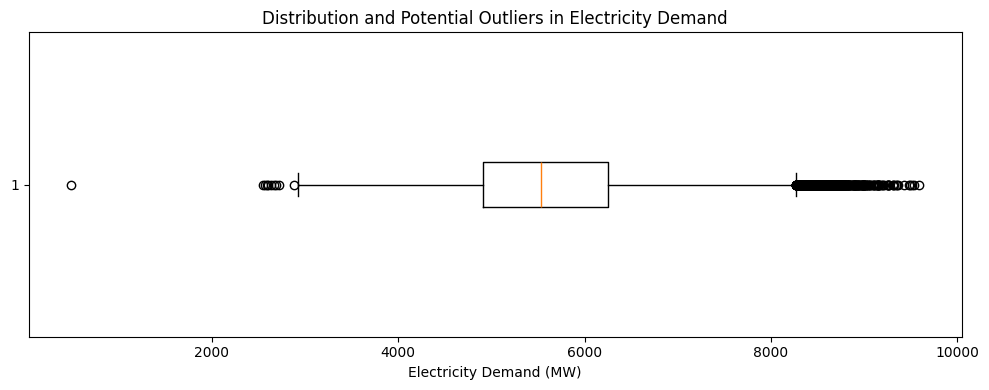

In [108]:
# BOXPLOT OF DEMAND

plt.figure(figsize=(10, 4))

plt.boxplot(
    df["PJMW_MW"],
    vert=False
)

plt.title(
    "Distribution and Potential Outliers in Electricity Demand"
)

plt.xlabel("Electricity Demand (MW)")

plt.tight_layout()
plt.show()

### INVESTIGATE VERY LOWEST DEMAND VALUE

In [109]:
# INVESTIGATE VERY LOW DEMAND VALUES

very_low = df[
    df["PJMW_MW"] < 1000
].sort_values("PJMW_MW")

print("Observations below 1000 MW:")
display(very_low)

Observations below 1000 MW:


,Datetime,PJMW_MW,Time_Difference
10148,2003-05-29,487,0 days 01:00:00


### Create cleaned demand column

For the specific 487 MW point, after inspecting the neighboring values, we can create a cleaned version.

In [110]:
# ============================================================
# 24. INVESTIGATE SUSPICIOUS OBSERVATION - finding out 3 values above & below 
# ============================================================

suspicious_index = df["PJMW_MW"].idxmin()

display(
    df.loc[
        suspicious_index - 3:
        suspicious_index + 3
    ]
)

,Datetime,PJMW_MW,Time_Difference
10145,2003-05-28 21:00:00,5631,0 days 01:00:00
10146,2003-05-28 22:00:00,5746,0 days 01:00:00
10147,2003-05-28 23:00:00,5317,0 days 01:00:00
10148,2003-05-29 00:00:00,487,0 days 01:00:00
10149,2003-05-29 01:00:00,4560,0 days 01:00:00
10150,2003-05-29 02:00:00,4424,0 days 01:00:00
10151,2003-05-29 03:00:00,4351,0 days 01:00:00


**Interplotaion** 

### Calculation

2003-05-29 00:00:00\
Original PJMW_MW       = 487 MW \
Interpolated Clean     = (5317+4560)/2 = 4938.5 MW

### Why is it the average?

Because the missing point is exactly **one hour between** the two known observations:

```text
23:00             00:00              01:00
5317 MW             ?                 4560 MW
   └────────────────┴──────────────────┘
          equal 1-hour intervals

In [111]:
# CREATE CLEANED DEMAND COLUMN

df["PJMW_MW_Clean"] = df["PJMW_MW"]

# Replace the identified suspicious observation
# with NaN first
df.loc[
    df["PJMW_MW"] < 1000,
    "PJMW_MW_Clean"
] = np.nan

In [112]:
# INTERPOLATE FLAGGED VALUE

df["PJMW_MW_Clean"] = (
    df["PJMW_MW_Clean"]
    .interpolate(method="linear")
)

In [113]:
# FLAG EXTREME OBSERVATIONS -> Consumption < 1000 MW

df["Possible_Anomaly"] = False

df.loc[
    df["PJMW_MW"] < 1000,
    "Possible_Anomaly"
] = True

display(
    df[df["Possible_Anomaly"]]
)

,Datetime,PJMW_MW,Time_Difference,PJMW_MW_Clean,Possible_Anomaly
10148,2003-05-29,487,0 days 01:00:00,4938.5,True


In [114]:
# COMPARE ORIGINAL AND CLEANED VALUES

comparison = df[
    df["Possible_Anomaly"]
][
    [
        "Datetime",
        "PJMW_MW",
        "PJMW_MW_Clean"
    ]
]

display(comparison)

,Datetime,PJMW_MW,PJMW_MW_Clean
10148,2003-05-29,487,4938.5


In [115]:
# Calculate Q1, Q3 and IQR
Q1 = df["PJMW_MW_Clean"].quantile(0.25)
Q3 = df["PJMW_MW_Clean"].quantile(0.75)

IQR = Q3 - Q1

# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find potential outliers
outliers = df[
    (df["PJMW_MW_Clean"] < lower_bound) | 
    (df["PJMW_MW_Clean"] > upper_bound)
]

# Print results
print("Q1:", Q1)
print("Median:", df["PJMW_MW_Clean"].median())
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Potential Outliers:", len(outliers))

Q1: 4907.0
Median: 5530.0
Q3: 6252.0
IQR: 1345.0
Lower Bound: 2889.5
Upper Bound: 8269.5
Number of Potential Outliers: 702


#### Low Demand Analysis (<2890 MW)

In [116]:
### Low Demand Analysis (<2890 MW)

low_demand = (
    df[df["PJMW_MW"] < 2890]
    .sort_values("PJMW_MW", ascending=False)
)

print("Number of observations below 2890 MW:", len(low_demand))

display(low_demand)

Number of observations below 2890 MW: 10


,Datetime,PJMW_MW,Time_Difference,PJMW_MW_Clean,Possible_Anomaly
87662,2012-04-01 13:00:00,2878,0 days 01:00:00,2878.0,False
87663,2012-04-01 14:00:00,2721,0 days 01:00:00,2721.0,False
87672,2012-04-01 23:00:00,2690,0 days 01:00:00,2690.0,False
87664,2012-04-01 15:00:00,2663,0 days 01:00:00,2663.0,False
87668,2012-04-01 19:00:00,2630,0 days 01:00:00,2630.0,False
87667,2012-04-01 18:00:00,2600,0 days 01:00:00,2600.0,False
87666,2012-04-01 17:00:00,2586,0 days 01:00:00,2586.0,False
87665,2012-04-01 16:00:00,2574,0 days 01:00:00,2574.0,False
87673,2012-04-02 00:00:00,2553,0 days 01:00:00,2553.0,False
10148,2003-05-29 00:00:00,487,0 days 01:00:00,4938.5,True


#### Low Demand Analysis (<2890 MW) Observation 

- There are **10 observations** 
- **9 observations** occur during **April 1–2, 2012**, mainly on **Sunday, April 1**.
- The low-demand values occur across several consecutive hours, indicating a **sustained low-demand period** rather than isolated abnormal values.
- The lowest value in this period is **2553 MW** at **April 2, 2012 00:00**.
- Most of these observations occur during the **weekend**, which may be associated with lower electricity demand.
- Therefore, low-demand observations should **not automatically be removed**; the April 2012 period may represent genuine low demand

#### High Demand Analysis

In [162]:
high_demand = (
    df[df["PJMW_MW"] > 8270]
    .sort_values("PJMW_MW", ascending=False)
)

print("Number of observations above 8270 MW:", len(high_demand))

# display(high_demand)

Number of observations above 8270 MW: 690


In [164]:
# YEAR-WISE OUTLIER SUMMARY

# Upper IQR outliers only
upper_outliers = df[
    df["PJMW_MW_Clean"] > upper_bound
].copy()

year_outlier_summary = (
    upper_outliers
    .groupby("Year")
    .agg(
        Upper_Outlier_Count=("PJMW_MW_Clean", "size"),
        Lowest_Upper_Outlier=("PJMW_MW_Clean", "min"),
        Highest_Upper_Outlier=("PJMW_MW_Clean", "max"),
        Distinct_Outlier_Values=("PJMW_MW_Clean", "nunique")
    )
    .reset_index()
)

display(year_outlier_summary)

,Year,Upper_Outlier_Count,Lowest_Upper_Outlier,Highest_Upper_Outlier,Distinct_Outlier_Values
0,2002,2,8270.0,8300.0,2
1,2003,4,8296.0,8437.0,4
2,2004,9,8289.0,8598.0,9
3,2005,111,8274.0,8823.0,93
4,2006,33,8285.0,8734.0,32
5,2007,23,8273.0,8664.0,22
6,2008,5,8276.0,8426.0,5
7,2009,12,8272.0,8541.0,11
8,2010,29,8270.0,8620.0,28
9,2011,29,8282.0,8998.0,29


In [165]:
# Compare different candidate upper limits

thresholds = [8500, 8750, 9000, 9250, 9500]

for threshold in thresholds:
    count = (df["PJMW_MW_Clean"] > threshold).sum()
    percentage = count / len(df) * 100

    print(
        f"Threshold: {threshold} MW | "
        f"Observations affected: {count} | "
        f"Percentage: {percentage:.4f}%"
    )

Threshold: 8500 MW | Observations affected: 330 | Percentage: 0.2304%
Threshold: 8750 MW | Observations affected: 129 | Percentage: 0.0901%
Threshold: 9000 MW | Observations affected: 50 | Percentage: 0.0349%
Threshold: 9250 MW | Observations affected: 17 | Percentage: 0.0119%
Threshold: 9500 MW | Observations affected: 3 | Percentage: 0.0021%


## Final Upper bound capping decision 

- 1 — Statistical outlier = 8269.5 MW => This is your IQR threshold.

- 2 — Extreme but potentially genuine demand

Approximately:

8,500–9,000 MW

- Level 3 — Extreme tail

Approximately:

9,000+ MW

There are **only 50 observations above 9,000 MW**, compared with 693 upper-IQR observations.

In [ ]:
# Insteresting finding about >9000 MW
high_demand = (
    df[df["PJMW_MW"] > 9000]
    .sort_values("PJMW_MW", ascending=False)
)

print("Number of observations above 9000 MW:", len(high_demand))

# display(high_demand)

#### Interesting finding about >9000 MW Observation 

- These high-demand observations are concentrated mainly in **January and February**, and all belong to the **Winter** season.
- Several high-demand observations occur consecutively, especially during **19–20 February 2015**, suggesting sustained periods of high electricity demand rather than isolated abnormal values.
- Many high-demand observations occur during **morning and evening hours**, particularly around **7–10 AM and 6–10 PM**.
- **Conlusion** These observations are better considered **extreme/high-demand periods** and should be retained for forecasting analysis.

In [ ]:
# # Final upper-tail capping
# UPPER_CAP = 9000

# df["PJMW_MW_Capped"] = df["PJMW_MW_Clean"].clip(upper=UPPER_CAP)

# print("Original Maximum:", df["PJMW_MW_Clean"].max())
# print("Capped Maximum:", df["PJMW_MW_Capped"].max())

# print(
#     "Number of observations capped:",
#     (df["PJMW_MW_Clean"] > UPPER_CAP).sum()
# )

____

### Creating all time features 

In [117]:
# CREATE TIME FEATURES

df["Year"] = df["Datetime"].dt.year
df["Month"] = df["Datetime"].dt.month
df["Month_Name"] = df["Datetime"].dt.month_name()

df["Day"] = df["Datetime"].dt.day
df["DayOfWeek"] = df["Datetime"].dt.dayofweek
df["Day_Name"] = df["Datetime"].dt.day_name()

df["Hour"] = df["Datetime"].dt.hour

df["WeekOfYear"] = df["Datetime"].dt.isocalendar().week
df["Quarter"] = df["Datetime"].dt.quarter

df["DayOfYear"] = df["Datetime"].dt.dayofyear

In [118]:
# Detailed data set 
df

,Datetime,PJMW_MW,Time_Difference,PJMW_MW_Clean,Possible_Anomaly,Year,Month,Month_Name,Day,DayOfWeek,Day_Name,Hour,WeekOfYear,Quarter,DayOfYear
0,2002-04-01 01:00:00,4374,NaT,4374.0,False,2002,4,April,1,0,Monday,1,14,2,91
1,2002-04-01 02:00:00,4306,0 days 01:00:00,4306.0,False,2002,4,April,1,0,Monday,2,14,2,91
2,2002-04-01 03:00:00,4322,0 days 01:00:00,4322.0,False,2002,4,April,1,0,Monday,3,14,2,91
3,2002-04-01 04:00:00,4359,0 days 01:00:00,4359.0,False,2002,4,April,1,0,Monday,4,14,2,91
4,2002-04-01 05:00:00,4436,0 days 01:00:00,4436.0,False,2002,4,April,1,0,Monday,5,14,2,91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143201,2018-08-02 20:00:00,6545,0 days 01:00:00,6545.0,False,2018,8,August,2,3,Thursday,20,31,3,214
143202,2018-08-02 21:00:00,6496,0 days 01:00:00,6496.0,False,2018,8,August,2,3,Thursday,21,31,3,214
143203,2018-08-02 22:00:00,6325,0 days 01:00:00,6325.0,False,2018,8,August,2,3,Thursday,22,31,3,214
143204,2018-08-02 23:00:00,5892,0 days 01:00:00,5892.0,False,2018,8,August,2,3,Thursday,23,31,3,214


____

## Autocorrelation Analysis 

### Does the current demand tell us something about demand one hour later, 24 hours later, or 168 hours later?

Autocorrelation → tells us how strongly demand is related to past demand at different lags.

- Lag 1   → Does the previous hour help explain current demand?
- Lag 24  → Does yesterday's same hour help explain current demand?
- Lag 168 (7 days) → Does last week's same hour help explain current demand?

In [119]:
# AUTOCORRELATION AT IMPORTANT LAGS

lag_1 = df["PJMW_MW_Clean"].autocorr(lag=1)
lag_24 = df["PJMW_MW_Clean"].autocorr(lag=24)
lag_168 = df["PJMW_MW_Clean"].autocorr(lag=168)

print(f"Lag 1 hour   : {lag_1:.4f}")
print(f"Lag 24 hours : {lag_24:.4f}")
print(f"Lag 168 hours: {lag_168:.4f}")

Lag 1 hour   : 0.9748
Lag 24 hours : 0.8773
Lag 168 hours: 0.7594


#### Autocorrelation Analysis – Observations

* **Lag 1 hour (0.9748) > Lag 24 hours (0.8773) > Lag 168 hours (0.7594)**
* The correlation decreases as the lag increases, but remains strong even after one week.
* **Forecasting Insight:** Previous demand values contain significant predictive information. 

- Lag features such as **24 hours and 168 hours** should therefore be considered during model building.


#### 1 week lag analysis

In [120]:
# AUTOCORRELATION FOR FIRST 7 DAYS

lags = range(1, 169)

autocorr_values = [
    df["PJMW_MW_Clean"].autocorr(lag=lag)
    for lag in lags
]

autocorr_df = pd.DataFrame({
    "Lag": lags,
    "Autocorrelation": autocorr_values
})

display(autocorr_df.head(55))

,Lag,Autocorrelation
0,1,0.974819
1,2,0.910291
2,3,0.820932
3,4,0.718994
4,5,0.614620
5,6,0.517544
6,7,0.435904
7,8,0.374257
8,9,0.332833
9,10,0.307815


## Autocorrelation Pattern – Observations

* Autocorrelation is very high at **lag 1 (0.9748)** and gradually decreases with increasing lag.
* It reaches a low point around **lag 13–14**, then starts increasing again.
* At **lag 24 (0.8773)**, the correlation becomes strong again, showing a clear **daily pattern**.
* This repeating pattern confirms that electricity demand has strong **hourly and daily dependence**.
* **Forecasting Insight:** Recent demand and 24-hour lag values are important features for forecasting.

| Lag | Autocorrelation | Pattern                          |
| --: | --------------: | -------------------------------- |
|   1 |          0.9748 | Very strong hourly relationship  |
|   6 |          0.4359 | Moderate short-term relationship |
|  12 |          0.2856 | Weak relationship                |
|  24 |          0.8773 | Strong daily pattern             |
| 168 |          0.7594 | Strong weekly pattern            |


## Yearly analysis

In [121]:
# YEARLY DEMAND

yearly_demand = (
    df
    .groupby("Year")["PJMW_MW_Clean"]
    .agg(
        Mean="mean",
        Median="median",
        Minimum="min",
        Maximum="max",
        Count="count"
    )
)

display(yearly_demand)

,Mean,Median,Minimum,Maximum,Count
Year,,,,,
2002,5621.663180,5575.0,3621.0,8300.0,6597
2003,5701.136504,5670.0,3677.0,8437.0,8758
2004,5866.616602,5852.5,3793.0,8598.0,8782
2005,6038.406029,5944.0,3837.0,8823.0,8758
2006,5425.448847,5366.0,3428.0,8734.0,8758
2007,5635.396780,5582.0,3466.0,8664.0,8758
2008,5530.132544,5470.0,3436.0,8426.0,8782
2009,5290.557433,5217.0,3213.0,8541.0,8758
2010,5573.025351,5456.0,3276.0,8620.0,8757


 Yearly average graph

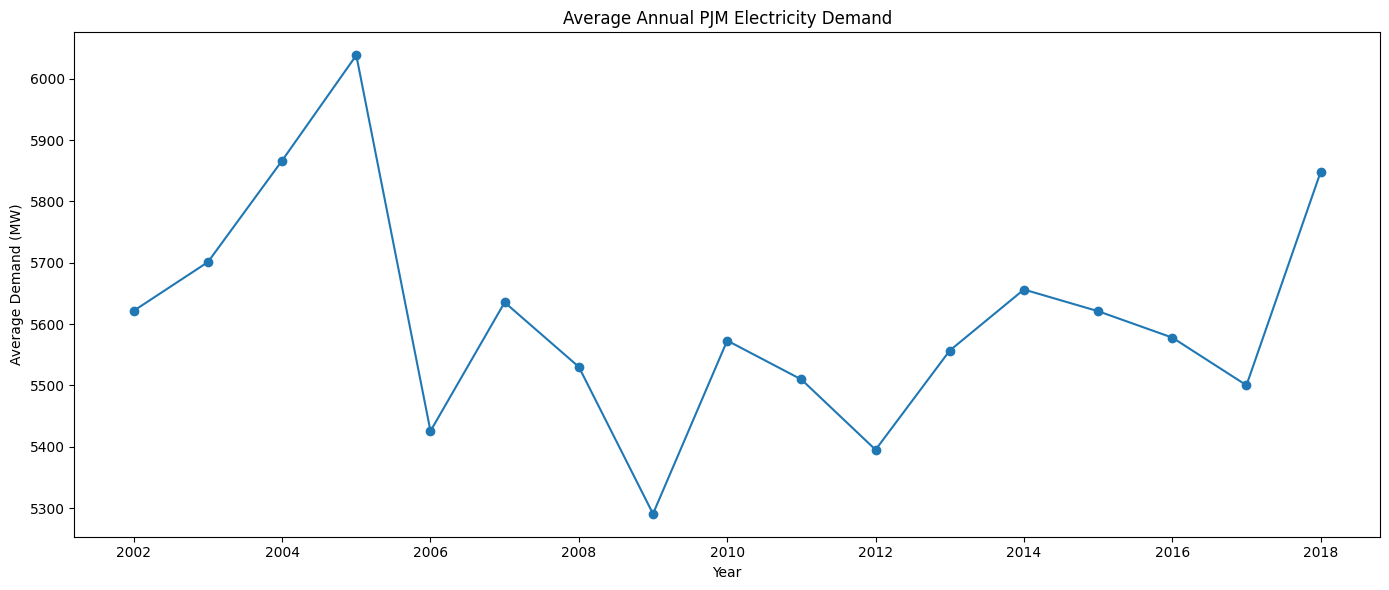

In [122]:
plt.figure(figsize=(14, 6))

plt.plot(
    yearly_demand.index,
    yearly_demand["Mean"],
    marker="o"
)

plt.title(
    "Average Annual PJM Electricity Demand"
)

plt.xlabel("Year")
plt.ylabel("Average Demand (MW)")

plt.tight_layout()
plt.show()

# look at Trend and Season

### DAILY AVERAGE POWER CONSUMPTION: 2013 vs 2014

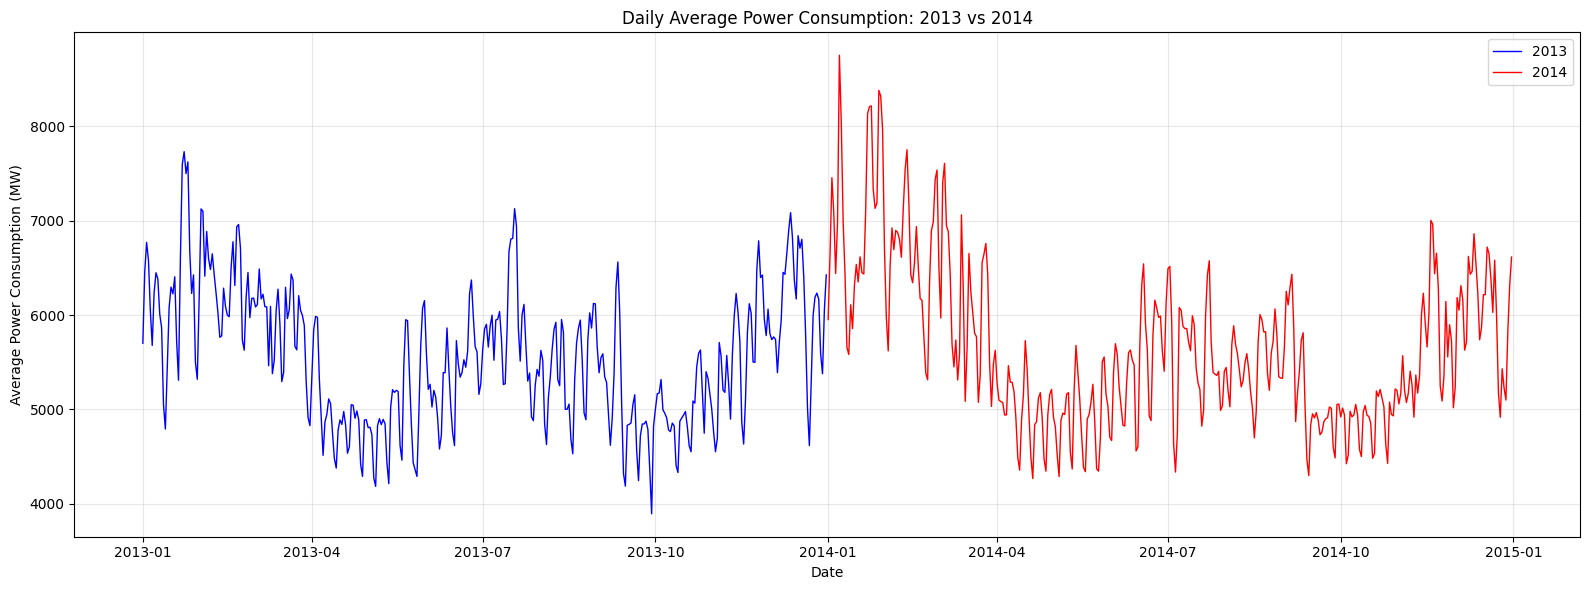

In [ ]:
# DAILY AVERAGE POWER CONSUMPTION: 2013 vs 2014

df_2013 = df[df["Year"] == 2013].copy()
df_2014 = df[df["Year"] == 2014].copy()

daily_2013 = (
    df_2013
    .set_index("Datetime")["PJMW_MW"]
    .resample("D")
    .mean()
)

daily_2014 = (
    df_2014
    .set_index("Datetime")["PJMW_MW"]
    .resample("D")
    .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(
    daily_2013.index,
    daily_2013.values,
    color="blue",
    linewidth=1,
    label="2013"
)

plt.plot(
    daily_2014.index,
    daily_2014.values,
    color="red",
    linewidth=1,
    label="2014"
)

plt.title("Daily Average Power Consumption: 2013 vs 2014")
plt.xlabel("Date")
plt.ylabel("Average Power Consumption (MW)")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

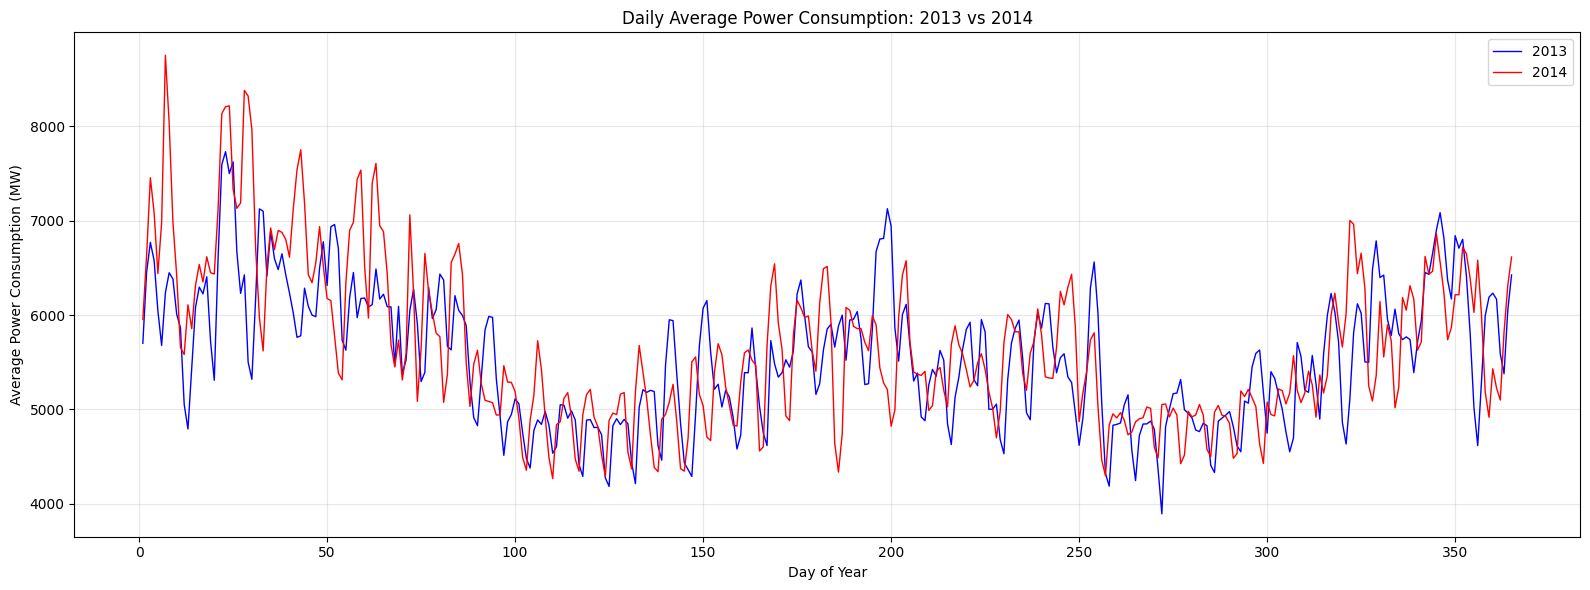

In [ ]:
# DAILY AVERAGE: COMPARE 2013 vs 2014
#     SAME MONTH/DAY SCALE

df_2013 = df[df["Year"] == 2013].copy()
df_2014 = df[df["Year"] == 2014].copy()

daily_2013 = (
    df_2013
    .groupby(df_2013["Datetime"].dt.dayofyear)["PJMW_MW"]
    .mean()
)

daily_2014 = (
    df_2014
    .groupby(df_2014["Datetime"].dt.dayofyear)["PJMW_MW"]
    .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(
    daily_2013.index,
    daily_2013.values,
    color="blue",
    linewidth=1,
    label="2013"
)

plt.plot(
    daily_2014.index,
    daily_2014.values,
    color="red",
    linewidth=1,
    label="2014"
)

plt.title("Daily Average Power Consumption: 2013 vs 2014")
plt.xlabel("Day of Year")
plt.ylabel("Average Power Consumption (MW)")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

### YEAR-OVER-YEAR CHANGE IN AVERAGE DEMAND

### Business hypothesis => 

Population ↑ + migration ↑ + industrial activity ↑ → electricity demand ↑ 

=> overall demand should increase from 2002 to 2018

In [123]:
overall_mean = df["PJMW_MW_Clean"].mean()

print("Overall Average Demand:", overall_mean)

Overall Average Demand: 5602.40617362401


In [124]:
# YEARLY AVERAGE POWER DEMAND

yearly_avg = (
    df.groupby("Year")["PJMW_MW_Clean"]
    .mean()
)

display(yearly_avg)

Year
2002    5621.663180
2003    5701.136504
2004    5866.616602
2005    6038.406029
2006    5425.448847
2007    5635.396780
2008    5530.132544
2009    5290.557433
2010    5573.025351
2011    5509.640215
2012    5395.010818
2013    5556.783626
2014    5656.334132
2015    5620.985616
2016    5577.929531
2017    5500.184361
2018    5848.157516
Name: PJMW_MW_Clean, dtype: float64

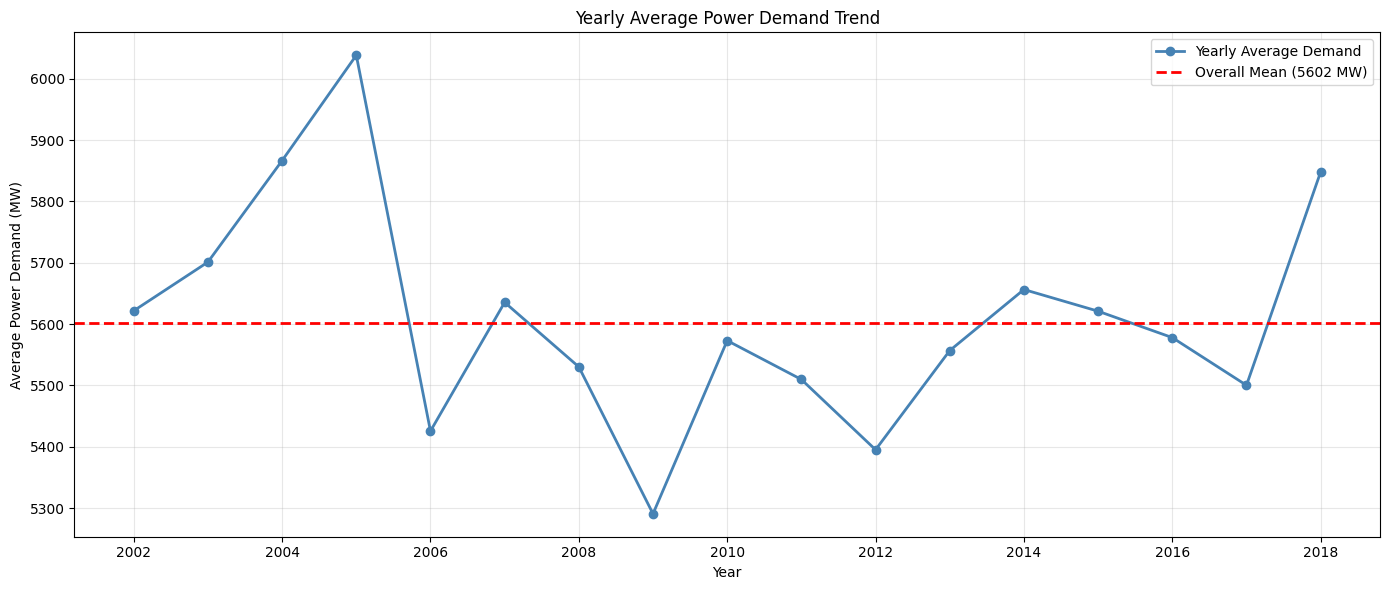

In [125]:
# ============================================================
# YEARLY AVERAGE POWER DEMAND TREND
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    yearly_avg.index,
    yearly_avg.values,
    marker="o",
    linewidth=2,
    color="steelblue",
    label="Yearly Average Demand"
)

# Reference line at 5500 MW
# plt.axhline(
#     y=5500,
#     color="red",
#     linestyle="--",
#     linewidth=2,
#     label="5500 MW Reference"
# )

plt.axhline(
    y=overall_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Overall Mean ({overall_mean:.0f} MW)"
)

plt.xlabel("Year")
plt.ylabel("Average Power Demand (MW)")
plt.title("Yearly Average Power Demand Trend")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Key Observations

* Electricity demand does **not increase continuously** every year. It shows fluctuations over time.
* From **2002 to 2005**, average demand increased from **5,621.66 MW to 6,038.41 MW**.
* **2006** shows a significant decrease to **5,425.45 MW**.
* **2009** has one of the lowest yearly averages at **5,290.56 MW**.
* From **2010 to 2014**, demand generally recovered and reached **5,656.33 MW** in 2014.
* From **2015 to 2017**, demand gradually decreased, reaching **5,500.18 MW** in 2017.
* In **2018**, demand increased again to **5,848.16 MW**.


* Overall, the data shows that electricity demand is affected by **multiple factors**, not just population growth or industrial development.
* The **5,500 MW line** is used only as a visual reference to compare yearly average demand.


____

# Seasonal analysis

#### U.S. Seasonal Classification


| Season | Months | Month Numbers |
|---|---|---|
| ❄️ Winter | December, January, February | 12, 1, 2 |
| 🌱 Spring | March, April, May | 3, 4, 5 |
| ☀️ Summer | June, July, August | 6, 7, 8 |
| 🍂 Fall | September, October, November | 9, 10, 11 |


In [126]:
# U.S. SEASON CLASSIFICATION

season_map = {
    12: "Winter",
    1: "Winter",
    2: "Winter",

    3: "Spring",
    4: "Spring",
    5: "Spring",

    6: "Summer",
    7: "Summer",
    8: "Summer",

    9: "Fall",
    10: "Fall",
    11: "Fall"
}

df["Season"] = df["Month"].map(season_map)

display(
    df[
        [
            "Datetime",
            "Month",
            "Month_Name",
            "Season"
        ]
    ].head(20)
)

,Datetime,Month,Month_Name,Season
0,2002-04-01 01:00:00,4,April,Spring
1,2002-04-01 02:00:00,4,April,Spring
2,2002-04-01 03:00:00,4,April,Spring
3,2002-04-01 04:00:00,4,April,Spring
4,2002-04-01 05:00:00,4,April,Spring
5,2002-04-01 06:00:00,4,April,Spring
6,2002-04-01 07:00:00,4,April,Spring
7,2002-04-01 08:00:00,4,April,Spring
8,2002-04-01 09:00:00,4,April,Spring
9,2002-04-01 10:00:00,4,April,Spring


In [127]:
# Set Season Order

season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Fall"
]

In [128]:
# SEASONAL DEMAND

seasonal_demand = (
    df
    .groupby("Season")["PJMW_MW_Clean"]
    .agg(
        Mean="mean",
        Median="median",
        Minimum="min",
        Maximum="max"
    )
    .reindex(season_order)
)

display(seasonal_demand)

,Mean,Median,Minimum,Maximum
Season,,,,
Winter,6268.813851,6258.0,3585.0,9594.0
Spring,5224.515840,5227.0,2553.0,8622.0
Summer,5734.206129,5688.0,3255.0,8998.0
Fall,5200.143147,5207.0,3197.0,8266.0


Seasonal plot

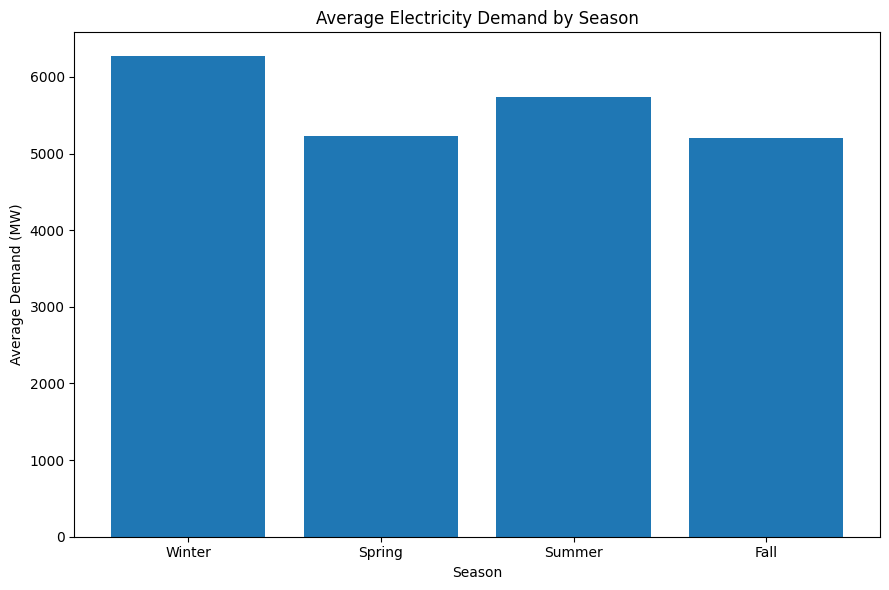

In [129]:
plt.figure(figsize=(9, 6))

plt.bar(
    seasonal_demand.index,
    seasonal_demand["Mean"]
)

plt.title(
    "Average Electricity Demand by Season"
)

plt.xlabel("Season")
plt.ylabel("Average Demand (MW)")

plt.tight_layout()
plt.show()

Hourly Behaviour as pre Season

In [130]:
# ============================================================
# 48. HOURLY PROFILE BY SEASON
# ============================================================

season_hourly = (
    df
    .groupby(
        ["Season", "Hour"]
    )["PJMW_MW_Clean"]
    .mean()
    .unstack(0)
)

display(season_hourly)

Season,Fall,Spring,Summer,Winter
Hour,,,,
0,4806.136676,4886.570822,5327.760417,5922.839917
1,4545.118819,4630.318982,4921.393485,5688.731994
2,4403.227210,4499.615786,4662.691205,5576.684903
3,4333.835852,4441.108839,4501.020847,5540.664820
4,4317.000000,4441.919765,4407.318567,5557.793629
5,4384.278846,4525.054142,4405.762866,5661.231994
6,4619.474588,4776.295499,4550.683388,5926.093490
7,5039.595467,5172.560339,4779.746580,6347.755540
8,5258.665522,5405.725375,5067.076873,6597.767313


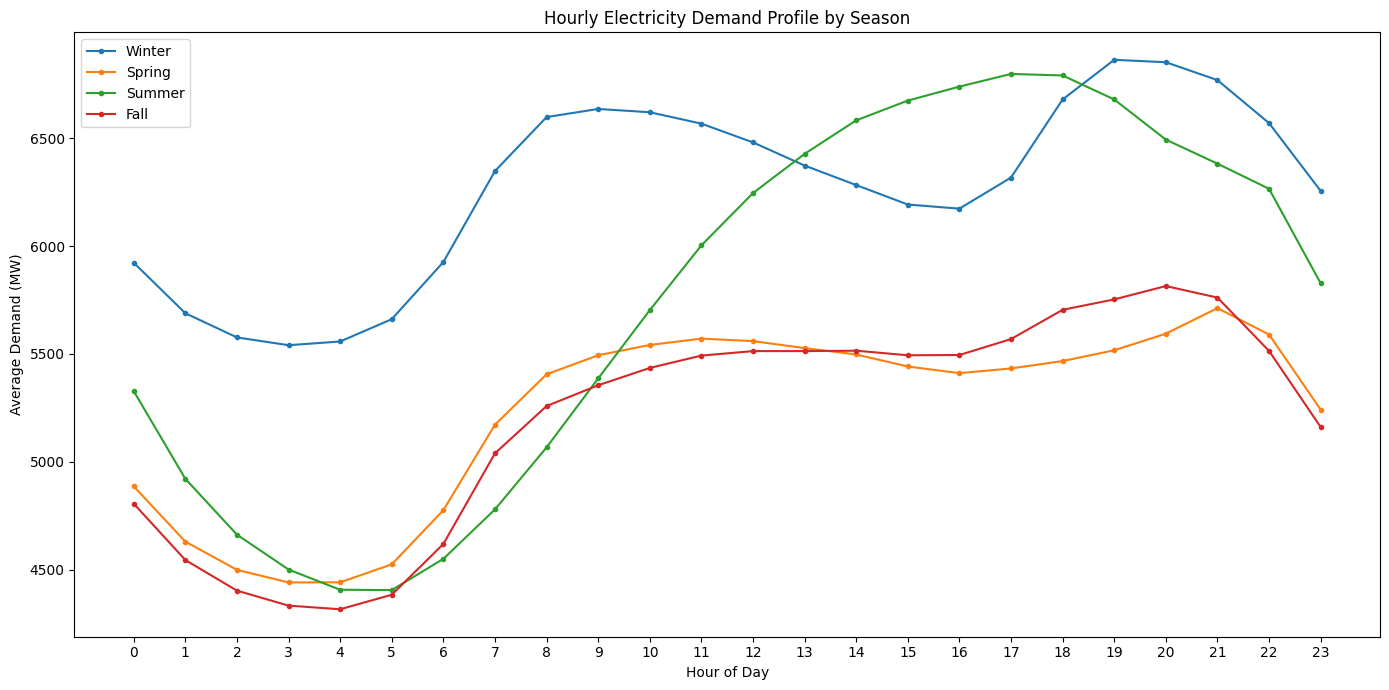

In [131]:
plt.figure(figsize=(14, 7))

for season in season_order:

    plt.plot(
        season_hourly.index,
        season_hourly[season],
        marker="o",
        markersize=3,
        label=season
    )

plt.title(
    "Hourly Electricity Demand Profile by Season"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (MW)")

plt.xticks(range(24))

plt.legend()

plt.tight_layout()
plt.show()

## Month Analysis

In [132]:
# ============================================================
# 44. MONTHLY DEMAND
# ============================================================

month_order = list(range(1, 13))

monthly_demand = (
    df
    .groupby("Month")["PJMW_MW_Clean"]
    .mean()
    .reindex(month_order)
)

display(
    monthly_demand.to_frame(
        name="Average_Demand_MW"
    )
)

,Average_Demand_MW
Month,
1,6447.667759
2,6296.808813
3,5654.097376
4,5022.310855
5,5016.197699
6,5516.756046
7,5861.537081
8,5822.142809
9,5205.872049


Monthly Plot

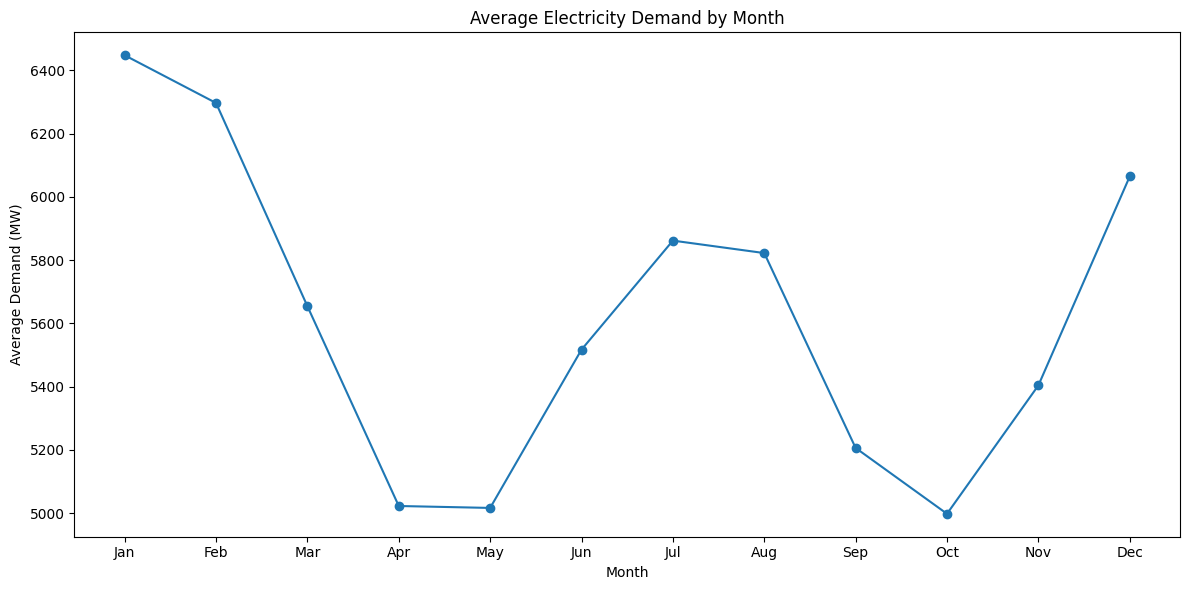

In [133]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_demand.index,
    monthly_demand.values,
    marker="o"
)

plt.title(
    "Average Electricity Demand by Month"
)

plt.xlabel("Month")
plt.ylabel("Average Demand (MW)")

plt.xticks(
    range(1, 13),
    [
        "Jan", "Feb", "Mar",
        "Apr", "May", "Jun",
        "Jul", "Aug", "Sep",
        "Oct", "Nov", "Dec"
    ]
)

plt.tight_layout()
plt.show()

Month + hour analysis

In [134]:
# ============================================================
# 50. MONTHLY HOURLY PROFILE
# ============================================================

month_hourly = (
    df
    .groupby(
        ["Month", "Hour"]
    )["PJMW_MW_Clean"]
    .mean()
    .unstack()
)

display(month_hourly)

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Month,,,,,,,,,,,,,,,,,,,,,
1,6066.701613,5846.125000,5744.000000,5714.372984,5733.824597,5836.754032,6105.453629,6522.723790,6790.247984,6821.002016,...,6485.151210,6389.147177,6369.600806,6506.760081,6883.614919,7046.054435,7018.899194,6925.897177,6716.556452,6401.252016
2,5965.500000,5756.856195,5664.373894,5639.356195,5665.035398,5774.393805,6051.477876,6493.586283,6708.566372,6725.325221,...,6292.141593,6190.223451,6150.840708,6235.396018,6471.378319,6792.044248,6821.787611,6742.006637,6544.628319,6244.477876
3,5325.233871,5117.151210,5021.641129,5001.956612,5020.395161,5134.528226,5419.360887,5868.661290,6089.157258,6103.687500,...,5737.939516,5632.358871,5570.792339,5594.094758,5674.989919,5856.645161,6047.854839,6096.000000,5916.258065,5606.622984
4,4690.776031,4447.550980,4324.039216,4276.259406,4283.160784,4371.398039,4631.650980,5051.403922,5265.805882,5341.901961,...,5269.768627,5202.666667,5160.380392,5167.260784,5185.511765,5203.811765,5295.374510,5515.935294,5379.007843,5035.445098
5,4662.818786,4348.996205,4178.210626,4083.990512,4051.110057,4100.130930,4311.036053,4634.654649,4897.901328,5067.546490,...,5491.867173,5494.290323,5503.586338,5538.398482,5544.203036,5500.850095,5456.024668,5541.563567,5487.218216,5099.248577
6,5133.729412,4737.149020,4493.323529,4346.854902,4266.764706,4276.674510,4427.547059,4661.156863,4985.056863,5287.047059,...,6274.719608,6342.835294,6398.394118,6454.443137,6450.915686,6358.711765,6203.633333,6086.278431,6040.041176,5634.482353
7,5460.648956,5039.225806,4762.104364,4585.269450,4478.612903,4465.341556,4594.208729,4782.825427,5089.514231,5444.434535,...,6779.366224,6874.796964,6939.478178,6996.806452,6989.309298,6876.929791,6675.565465,6503.290323,6406.195446,5975.654649
8,5385.723447,4985.383534,4730.937751,4569.746988,4475.813253,4474.913655,4630.726908,4897.935743,5127.329317,5427.566265,...,6689.997992,6801.196787,6875.622490,6938.759036,6928.044177,6798.853414,6597.429719,6556.002008,6347.431727,5868.495984
9,4778.172917,4460.281250,4270.660417,4159.691667,4103.233333,4131.070833,4327.906250,4718.191667,4909.970833,5085.262500,...,5810.979167,5864.664583,5908.420833,5960.756250,5955.045833,5868.018750,5895.647917,5909.270833,5605.489583,5180.208333


Plot Month vs Hours Distribution

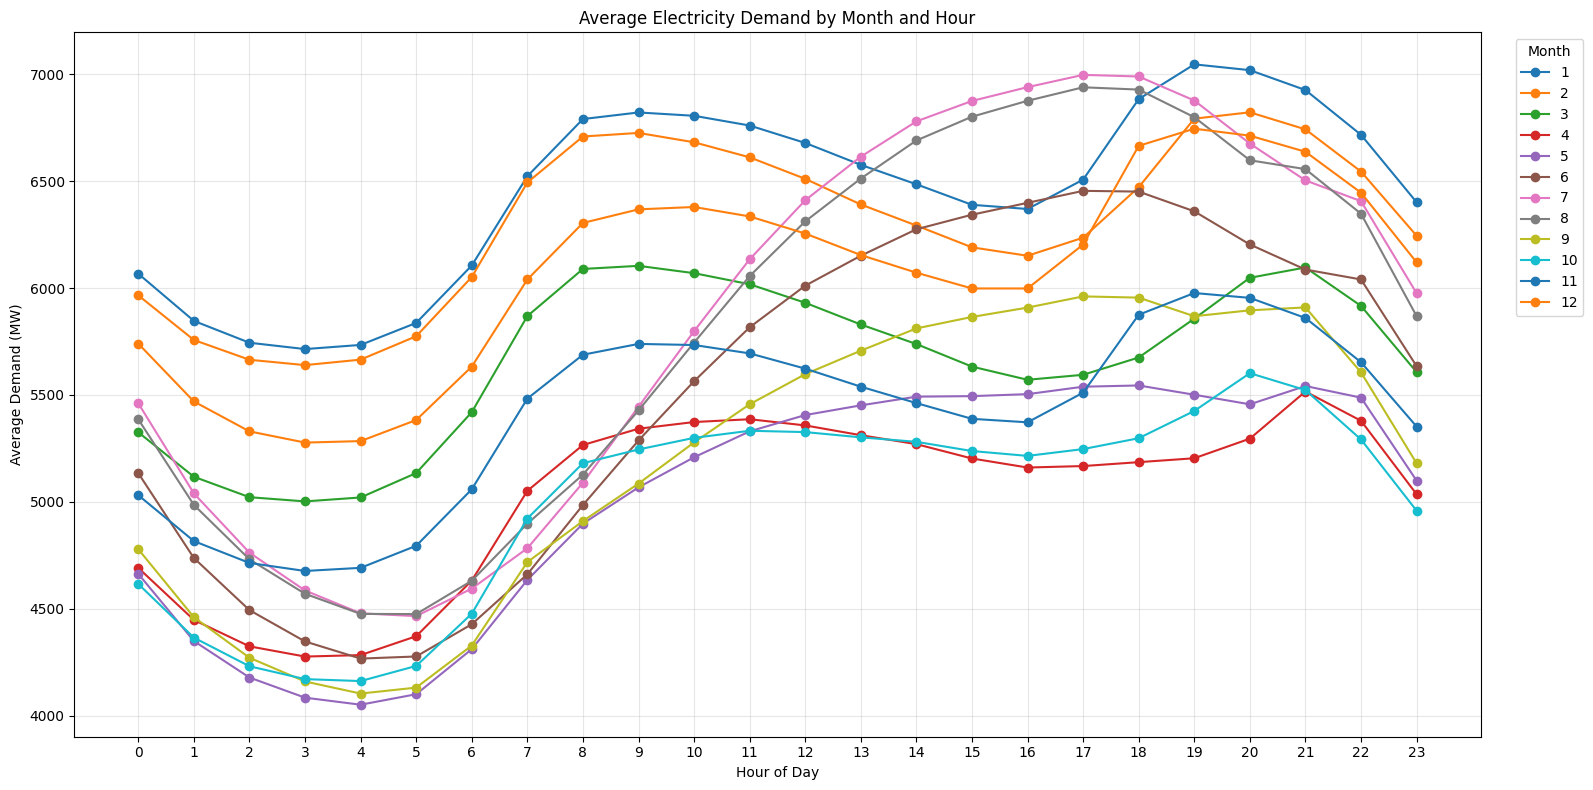

In [135]:
# ============================================================
# 51. MONTH VS HOUR - LINE CHART
# ============================================================

plt.figure(figsize=(16, 8))

for month in month_hourly.index:
    plt.plot(
        month_hourly.columns,
        month_hourly.loc[month],
        marker="o",
        linewidth=1.5,
        label=month
    )

plt.title("Average Electricity Demand by Month and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (MW)")

plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.legend(
    title="Month",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Week Analysis

i.e DAY OF WEEK ANALYSIS

In [136]:
# ============================================================
# 42. DAY OF WEEK ANALYSIS
# ============================================================

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_demand = (
    df
    .groupby("Day_Name")["PJMW_MW_Clean"]
    .mean()
    .reindex(day_order)
)

display(
    daily_demand.to_frame(
        name="Average_Demand_MW"
    )
)

,Average_Demand_MW
Day_Name,
Monday,5700.518783
Tuesday,5801.076837
Wednesday,5802.370701
Thursday,5781.058495
Friday,5686.839202
Saturday,5293.999413
Sunday,5149.638300


Plot Day-of-Week demand

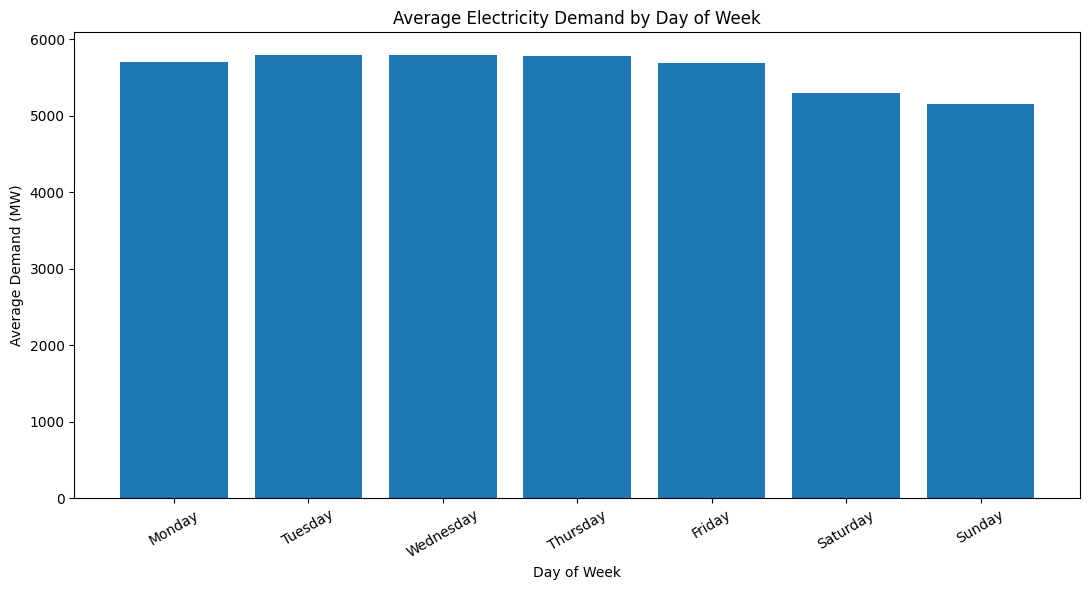

In [137]:
plt.figure(figsize=(11, 6))

plt.bar(
    daily_demand.index,
    daily_demand.values
)

plt.title(
    "Average Electricity Demand by Day of Week"
)

plt.xlabel("Day of Week")
plt.ylabel("Average Demand (MW)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Weekday vs Weekend

In [138]:
# WEEKEND FEATURE

df["Is_Weekend"] = (
    df["DayOfWeek"] >= 5
).astype(int)

df["Day_Type"] = np.where(
    df["Is_Weekend"] == 1,
    "Weekend",
    "Weekday"
)

display(
    df[
        [
            "Datetime",
            "Day_Name",
            "Is_Weekend",
            "Day_Type"
        ]
    ].head(24*7)
)

,Datetime,Day_Name,Is_Weekend,Day_Type
0,2002-04-01 01:00:00,Monday,0,Weekday
1,2002-04-01 02:00:00,Monday,0,Weekday
2,2002-04-01 03:00:00,Monday,0,Weekday
3,2002-04-01 04:00:00,Monday,0,Weekday
4,2002-04-01 05:00:00,Monday,0,Weekday
...,...,...,...,...
163,2002-04-07 21:00:00,Sunday,1,Weekend
164,2002-04-07 22:00:00,Sunday,1,Weekend
165,2002-04-07 23:00:00,Sunday,1,Weekend
166,2002-04-08 00:00:00,Monday,0,Weekday


In [139]:
# WEEKDAY VS WEEKEND

weekday_weekend = (
    df
    .groupby("Day_Type")["PJMW_MW_Clean"]
    .agg(
        Mean="mean",
        Median="median",
        Minimum="min",
        Maximum="max"
    )
)

display(weekday_weekend)

,Mean,Median,Minimum,Maximum
Day_Type,,,,
Weekday,5754.389168,5671.0,2553.0,9594.0
Weekend,5221.863008,5136.0,2574.0,9003.0


Plot Weekday vs Weekend

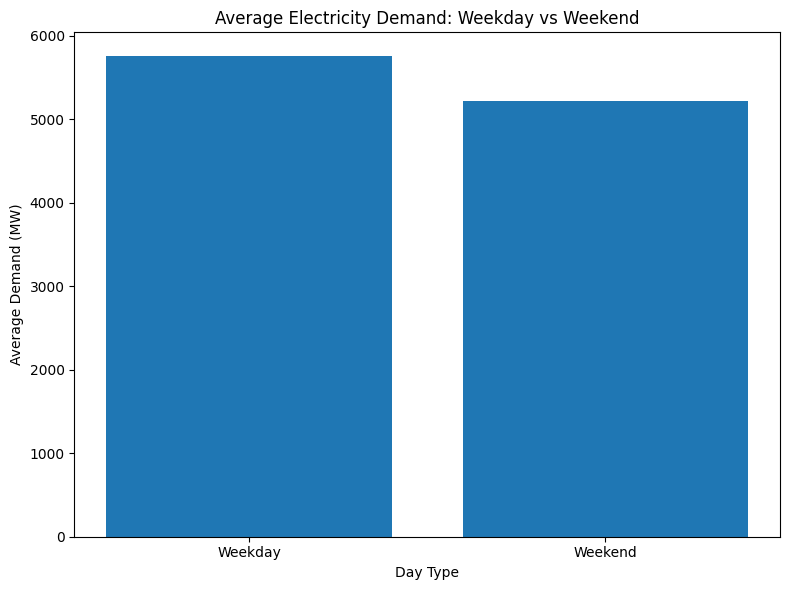

In [140]:
plt.figure(figsize=(8, 6))

plt.bar(
    weekday_weekend.index,
    weekday_weekend["Mean"]
)

plt.title(
    "Average Electricity Demand: Weekday vs Weekend"
)

plt.xlabel("Day Type")
plt.ylabel("Average Demand (MW)")

plt.tight_layout()
plt.show()

## Hourly Analysis

i.e. Hour-of-day analysis

In [141]:
# ============================================================
# 40. AVERAGE DEMAND BY HOUR
# ============================================================

hourly_demand = (
    df
    .groupby("Hour")["PJMW_MW_Clean"]
    .mean()
)

display(
    hourly_demand.to_frame(
        name="Average_Demand_MW"
    )
)

,Average_Demand_MW
Hour,
0,5231.114379
1,4940.489276
2,4779.152349
3,4697.121996
4,4672.537366
5,4734.933479
6,4958.209450
7,5323.434316
8,5571.168398


Plot Hourly Demand

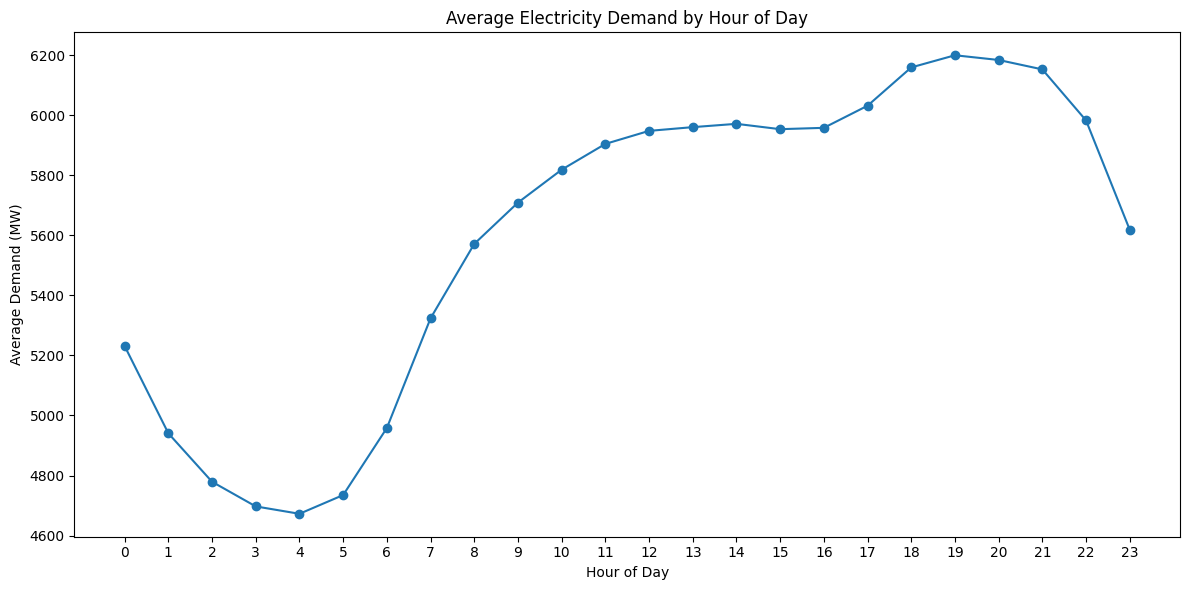

In [142]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_demand.index,
    hourly_demand.values,
    marker="o"
)

plt.title(
    "Average Electricity Demand by Hour of Day"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (MW)")

plt.xticks(range(24))

plt.tight_layout()
plt.show()

____

## Holiday analysis

#### Major U.S. Holidays for Electricity Consumption Analysis

| Holiday | Date / Rule |
|---|---|
| New Year's Day | January 1 |
| Martin Luther King Jr. Day | 3rd Monday of January |
| Presidents' Day | 3rd Monday of February |
| Memorial Day | Last Monday of May |
| Independence Day | July 4 |
| Labor Day | 1st Monday of September |
| Thanksgiving Day | 4th Thursday of November |
| Day After Thanksgiving (Black Friday) | Friday after Thanksgiving |
| Christmas Eve | December 24 |
| Christmas Day | December 25 |
| New Year's Eve | December 31 |

In [ ]:
# HOLIDAY FUNCTIONS

def nth_weekday(year, month, weekday, n):
    """
    Return the date of the nth weekday in a month.

    weekday:
        Monday = 0
        Tuesday = 1
        ...
        Sunday = 6
    """

    dates = pd.date_range(
        start=f"{year}-{month:02d}-01",
        end=f"{year}-{month:02d}-28"
    )

    matching_days = dates[
        dates.weekday == weekday
    ]

    return matching_days[n - 1]


def last_weekday(year, month, weekday):
    """
    Return the date of the last specified weekday
    in a month.
    """

    start = pd.Timestamp(
        year=year,
        month=month,
        day=1
    )

    end = (
        start
        + pd.offsets.MonthEnd(1)
    )

    dates = pd.date_range(
        start=start,
        end=end
    )

    matching_days = dates[
        dates.weekday == weekday
    ]

    return matching_days[-1]

In [ ]:
# CREATE HOLIDAY CALENDAR

def create_us_holidays(start_year, end_year):

    holiday_dict = {}

    for year in range(start_year, end_year + 1):

        # New Year's Day
        holiday_dict[
            pd.Timestamp(year, 1, 1)
        ] = "New Year's Day"

        # Martin Luther King Jr. Day
        mlk = nth_weekday(
            year,
            1,
            0,
            3
        )

        holiday_dict[mlk] = (
            "Martin Luther King Jr. Day"
        )

        # Presidents' Day
        presidents = nth_weekday(
            year,
            2,
            0,
            3
        )

        holiday_dict[presidents] = (
            "Presidents' Day"
        )

        # Memorial Day
        memorial = last_weekday(
            year,
            5,
            0
        )

        holiday_dict[memorial] = (
            "Memorial Day"
        )

        # Independence Day
        holiday_dict[
            pd.Timestamp(year, 7, 4)
        ] = "Independence Day"

        # Labor Day
        labor = nth_weekday(
            year,
            9,
            0,
            1
        )

        holiday_dict[labor] = "Labor Day"

        # Thanksgiving
        thanksgiving = nth_weekday(
            year,
            11,
            3,
            4
        )

        holiday_dict[thanksgiving] = (
            "Thanksgiving Day"
        )

        # Black Friday
        black_friday = (
            thanksgiving
            + pd.Timedelta(days=1)
        )

        holiday_dict[black_friday] = (
            "Day After Thanksgiving"
        )

        # Christmas Eve
        holiday_dict[
            pd.Timestamp(year, 12, 24)
        ] = "Christmas Eve"

        # Christmas Day
        holiday_dict[
            pd.Timestamp(year, 12, 25)
        ] = "Christmas Day"

        # New Year's Eve
        holiday_dict[
            pd.Timestamp(year, 12, 31)
        ] = "New Year's Eve"

    return holiday_dict

In [ ]:
# GENERATE HOLIDAY CALENDAR

start_year = df["Year"].min()
end_year = df["Year"].max()

holiday_calendar = create_us_holidays(
    start_year,
    end_year
)

print(
    "Number of holiday dates created:",
    len(holiday_calendar)
)

Number of holiday dates created: 187


Add holiday information to dataset

In [ ]:
# ADD HOLIDAY INFORMATION

df["Holiday_Name"] = (
    df["Datetime"]
    .dt.normalize()
    .map(holiday_calendar)
)

df["Is_Holiday"] = (
    df["Holiday_Name"]
    .notna()
    .astype(int)
)

df["Holiday_Name"] = (
    df["Holiday_Name"]
    .fillna("None")
)

In [147]:
display(
    df[
        df["Is_Holiday"] == 1
    ][
        [
            "Datetime",
            "Holiday_Name",
            "PJMW_MW_Clean"
        ]
    ].head(30)
)

,Datetime,Holiday_Name,PJMW_MW_Clean
1342,2002-05-27 00:00:00,Memorial Day,4307.0
1343,2002-05-27 01:00:00,Memorial Day,4023.0
1344,2002-05-27 02:00:00,Memorial Day,3871.0
1345,2002-05-27 03:00:00,Memorial Day,3801.0
1346,2002-05-27 04:00:00,Memorial Day,3745.0
1347,2002-05-27 05:00:00,Memorial Day,3712.0
1348,2002-05-27 06:00:00,Memorial Day,3728.0
1349,2002-05-27 07:00:00,Memorial Day,3797.0
1350,2002-05-27 08:00:00,Memorial Day,3986.0
1351,2002-05-27 09:00:00,Memorial Day,4358.0


In [148]:
# ============================================================
# 55. HOLIDAY VS NON-HOLIDAY
# ============================================================

holiday_summary = (
    df
    .groupby("Is_Holiday")["PJMW_MW_Clean"]
    .agg(
        Mean="mean",
        Median="median",
        Minimum="min",
        Maximum="max",
        Count="count"
    )
)

holiday_summary.index = [
    "Non-Holiday",
    "Holiday"
]

display(holiday_summary)

,Mean,Median,Minimum,Maximum,Count
Non-Holiday,5604.495030,5532.0,2553.0,9594.0,138934
Holiday,5534.472378,5466.0,3286.0,9187.0,4272


Holiday vs non-holiday graph

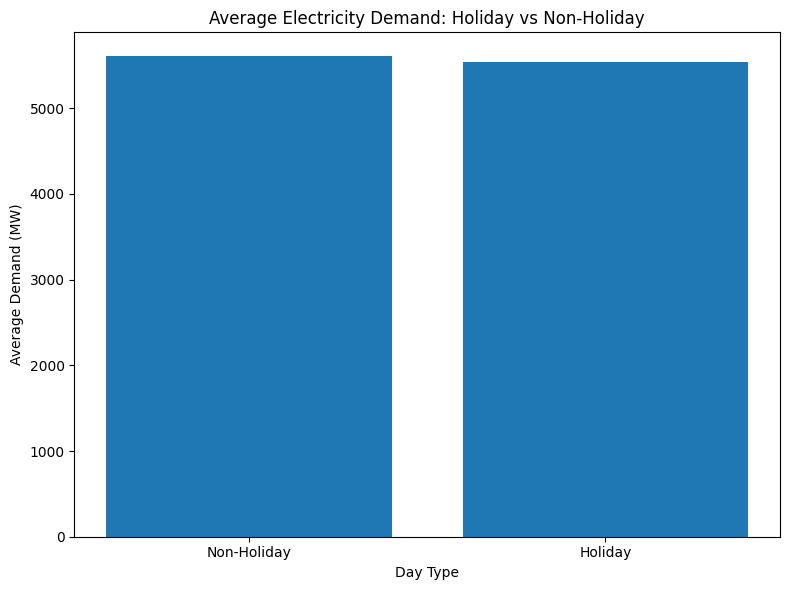

In [149]:
plt.figure(figsize=(8, 6))

plt.bar(
    holiday_summary.index,
    holiday_summary["Mean"]
)

plt.title(
    "Average Electricity Demand: Holiday vs Non-Holiday"
)

plt.xlabel("Day Type")
plt.ylabel("Average Demand (MW)")

plt.tight_layout()
plt.show()

In [150]:
# HOLIDAY DEMAND BY SEASON


holiday_season = (
    df
    .groupby(
        ["Season", "Is_Holiday"]
    )["PJMW_MW_Clean"]
    .mean()
    .unstack()
)

holiday_season.columns = [
    "Non-Holiday",
    "Holiday"
]

display(holiday_season)

,Non-Holiday,Holiday
Season,,
Fall,5203.286852,5107.949653
Spring,5228.403303,4878.017157
Summer,5739.756786,5238.551471
Winter,6293.913511,5916.383681


_____

### Season × day × hour

In [151]:
#  SEASON + DAY TYPE + HOUR

season_day_hour = (
    df
    .groupby(
        [
            "Season",
            "Day_Type",
            "Hour"
        ]
    )["PJMW_MW_Clean"]
    .mean()
)

display(
    season_day_hour.head(30)
)

Season  Day_Type  Hour
Fall    Weekday   0       4853.503846
                  1       4595.413462
                  2       4459.230769
                  3       4396.199038
                  4       4386.921154
                  5       4474.313462
                  6       4767.078846
                  7       5289.325000
                  8       5520.840385
                  9       5561.876923
                  10      5606.978846
                  11      5661.685577
                  12      5684.164423
                  13      5686.623077
                  14      5697.549038
                  15      5678.563462
                  16      5676.377885
                  17      5743.481731
                  18      5868.629808
                  19      5913.926923
                  20      5974.640385
                  21      5915.262500
                  22      5653.298077
                  23      5273.250962
        Weekend   0       4687.718750
                  1       4

Hour on the X-axis, Demand on the Y-axis, and separate colored lines for the Season + Day Type combinations.

That gives you 8 distinct lines:

- Winter – Weekday
- Winter – Weekend
- Spring – Weekday
- Spring – Weekend
- Summer – Weekday
- Summer – Weekend
- Fall – Weekday
- Fall – Weekend

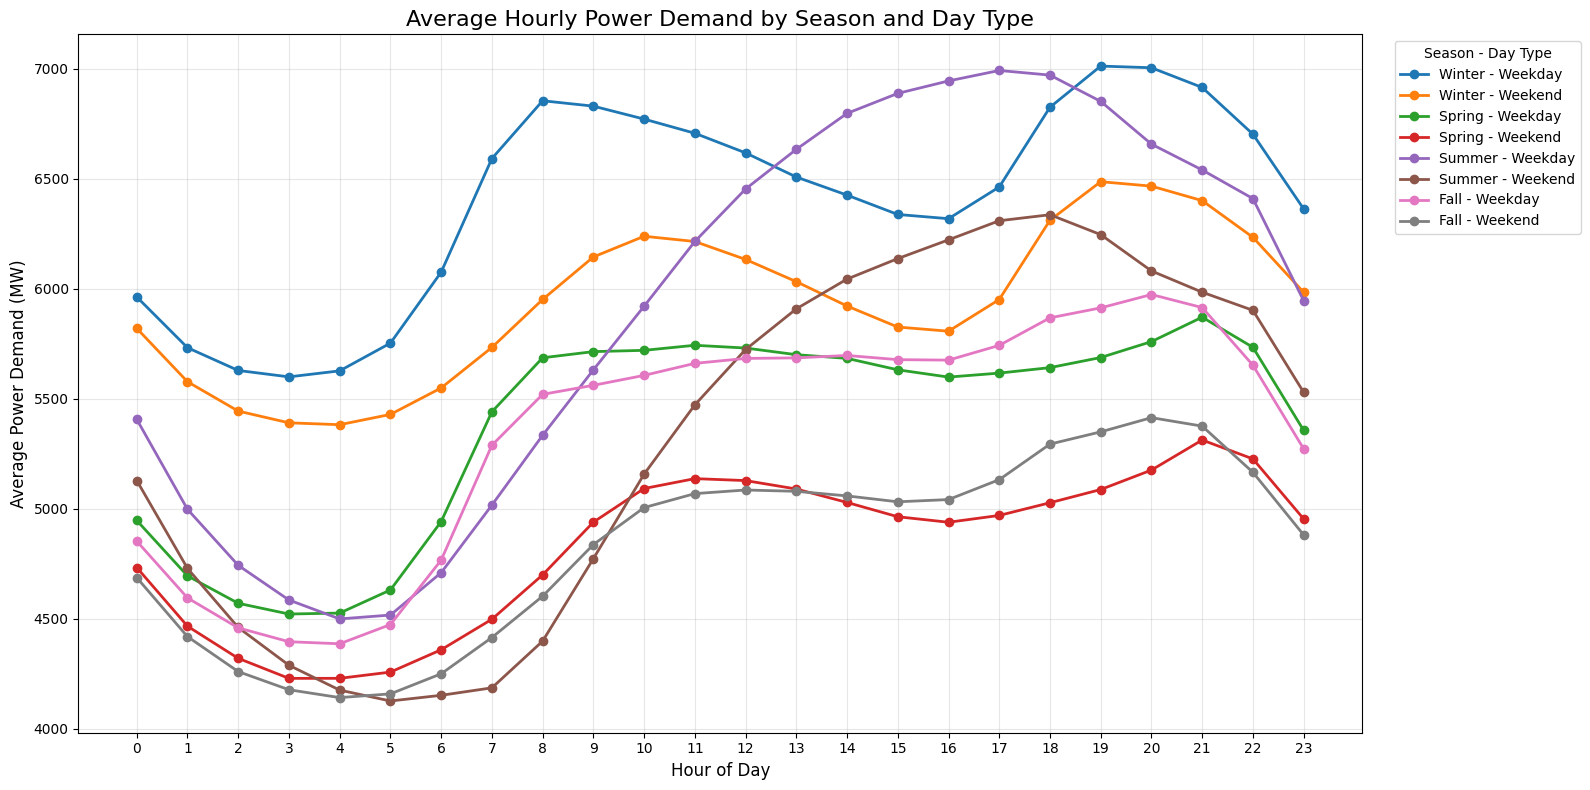

In [152]:
# Ploting SEASON + DAY TYPE + HOUR
# Hourly demand profile by Season and Day Type

# Calculate average demand
season_day_hour = (
    df.groupby(
        ["Season", "Day_Type", "Hour"]
    )["PJMW_MW_Clean"]
    .mean()
    .reset_index()
)

# Season order
season_order = ["Winter", "Spring", "Summer", "Fall"]

# Day type order
day_type_order = ["Weekday", "Weekend"]

# Create one figure
plt.figure(figsize=(16, 8))

# Plot each Season + Day Type combination
for season in season_order:
    
    for day_type in day_type_order:
        
        temp = season_day_hour[
            (season_day_hour["Season"] == season) &
            (season_day_hour["Day_Type"] == day_type)
        ]
        
        plt.plot(
            temp["Hour"],
            temp["PJMW_MW_Clean"],
            marker="o",
            linewidth=2,
            label=f"{season} - {day_type}"
        )

# Graph formatting
plt.title(
    "Average Hourly Power Demand by Season and Day Type",
    fontsize=16
)

plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Average Power Demand (MW)", fontsize=12)

plt.xticks(range(24))

plt.legend(
    title="Season - Day Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

____

___

### Rolling Mean And Rolling Standard Deviation -> Check data is stationary 

From 2002-2018 claculating 24-hours & 168-hours i.e 7 days window rolling mean and standard deviation

In [153]:
# 24-hour rolling features
df["Rolling_Mean_24"] = (
    df["PJMW_MW_Clean"]
    .rolling(window=24)
    .mean()
)

df["Rolling_Std_24"] = (
    df["PJMW_MW_Clean"]
    .rolling(window=24)
    .std()
)

# 168-hour (7-day) rolling features
df["Rolling_Mean_168"] = (
    df["PJMW_MW_Clean"]
    .rolling(window=168)
    .mean()
)

df["Rolling_Std_168"] = (
    df["PJMW_MW_Clean"]
    .rolling(window=168)
    .std()
)

In [154]:
# Display 24 & 168 hours rolling data -> last 55 enteries 
display(
    df[
        [
            "Datetime",
            "PJMW_MW_Clean",
            "Rolling_Mean_24",
            "Rolling_Std_24",
            "Rolling_Mean_168",
            "Rolling_Std_168"
        ]
    ].tail(55)
)

,Datetime,PJMW_MW_Clean,Rolling_Mean_24,Rolling_Std_24,Rolling_Mean_168,Rolling_Std_168
143151,2018-07-31 18:00:00,6480.0,5622.833333,780.144227,5753.559524,917.919169
143152,2018-07-31 19:00:00,6426.0,5632.791667,789.132379,5749.779762,913.801367
143153,2018-07-31 20:00:00,6276.0,5637.125000,792.500408,5746.083333,910.382557
143154,2018-07-31 21:00:00,6250.0,5644.750000,797.679692,5742.922619,907.685746
143155,2018-07-31 22:00:00,6123.0,5653.625000,801.932764,5740.029762,905.681213
143156,2018-07-31 23:00:00,5771.0,5660.750000,802.195208,5737.785714,905.131202
143157,2018-08-01 00:00:00,5343.0,5668.916667,797.722842,5735.255952,905.640026
143158,2018-08-01 01:00:00,5061.0,5677.833333,789.287718,5733.613095,906.616609
143159,2018-08-01 02:00:00,4817.0,5689.583333,773.475494,5732.083333,907.952097
143160,2018-08-01 03:00:00,4687.0,5697.708333,761.276473,5730.791667,909.290563


### Observation: Rolling Mean and Rolling Standard Deviation

* The **24-hour rolling standard deviation** is around **700–910 MW**, showing that demand has considerable variation within a day.
* The 168-hour rolling standard deviation is generally around **850–920 MW**, showing that demand variability also exists across the weekly period.
* When the rolling standard deviation decreases, demand is relatively more stable; when it increases, demand is more variable.
* The rolling statistics provide the model with information about both the **recent demand level** and **recent demand variability**.

### Observation: Data is NOT Stationarity

- The rolling mean is not constant over time, indicating that the average demand level changes.
- The rolling standard deviation also changes over time, indicating that demand variability is not constant.
- Therefore, the electricity demand series appears to be **non-stationary**.
- The series also shows strong daily and weekly patterns, as indicated by the high autocorrelation at lag 24 and lag 168.
- This means the forecasting model needs to account for **changing demand levels, variability, and seasonality**.

Ploting Rolling Mean and Standard Deviation for 2002-2018

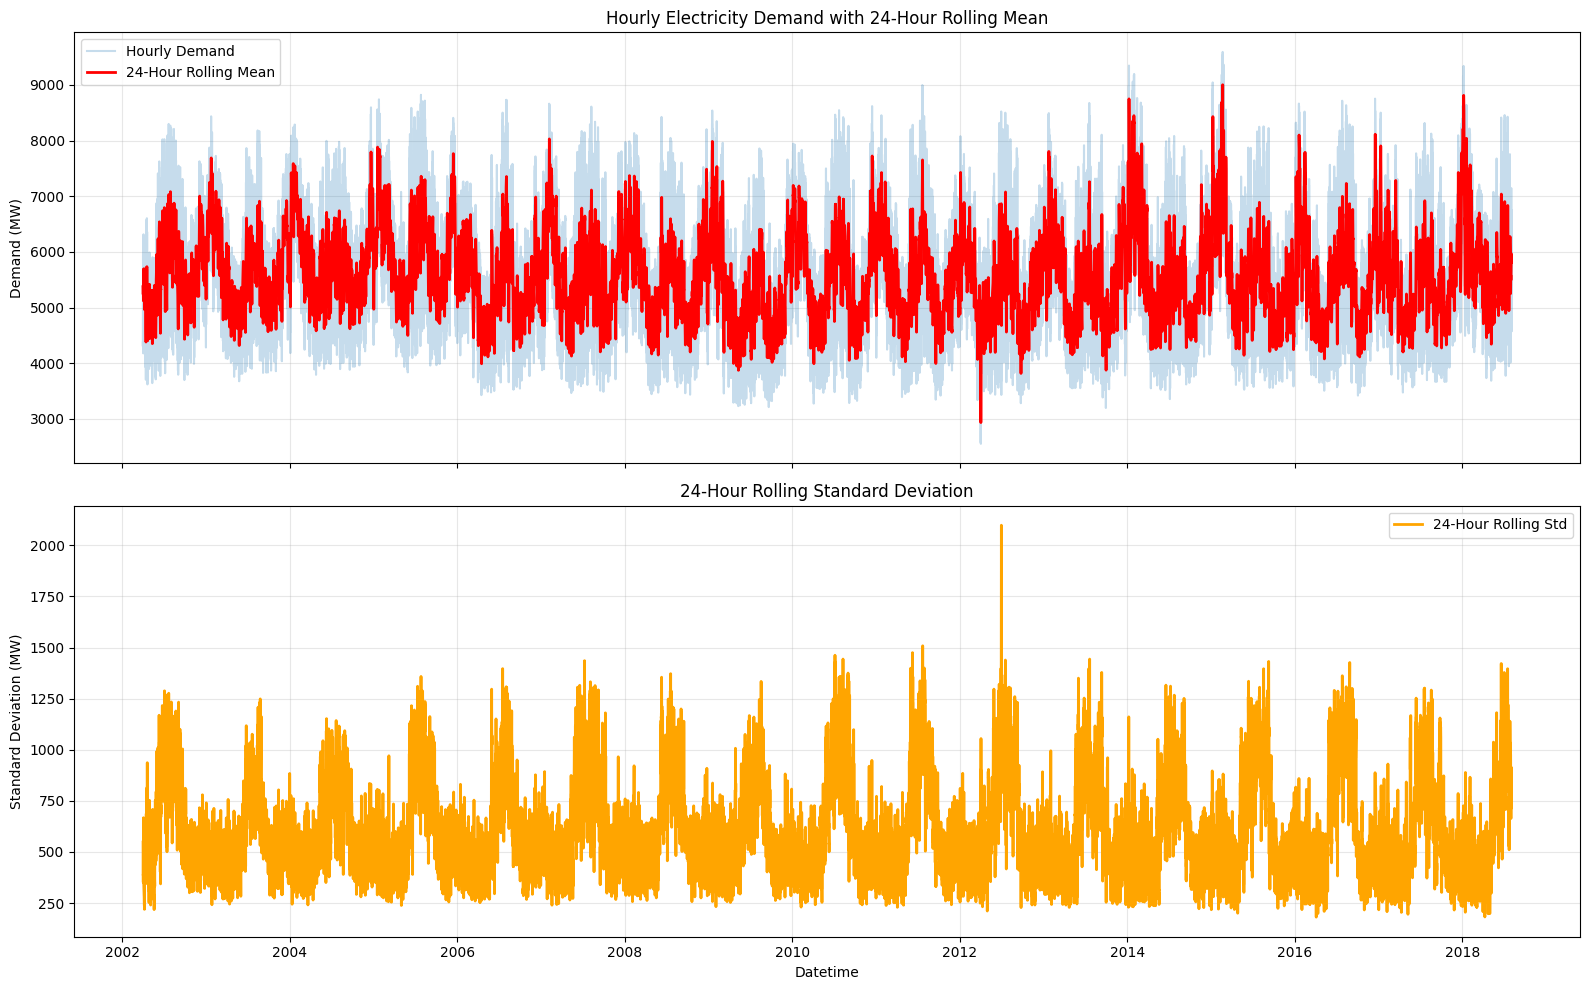

In [155]:
# 24-HOUR ROLLING MEAN AND STANDARD DEVIATION

fig, axes = plt.subplots(
    2, 1,
    figsize=(16, 10),
    sharex=True
)

# ------------------------------------------------------------
# Rolling Mean
# ------------------------------------------------------------

axes[0].plot(
    df["Datetime"],
    df["PJMW_MW_Clean"],
    alpha=0.25,
    label="Hourly Demand"
)

axes[0].plot(
    df["Datetime"],
    df["Rolling_Mean_24"],
    linewidth=2,
    color="red",
    label="24-Hour Rolling Mean"
)

axes[0].set_title(
    "Hourly Electricity Demand with 24-Hour Rolling Mean"
)

axes[0].set_ylabel("Demand (MW)")
axes[0].legend()
axes[0].grid(alpha=0.3)


# ------------------------------------------------------------
# Rolling Standard Deviation
# ------------------------------------------------------------

axes[1].plot(
    df["Datetime"],
    df["Rolling_Std_24"],
    linewidth=2,
    color="orange",
    label="24-Hour Rolling Std"
)

axes[1].set_title(
    "24-Hour Rolling Standard Deviation"
)

axes[1].set_xlabel("Datetime")
axes[1].set_ylabel("Standard Deviation (MW)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Ploting Rolling Mean & Standard deviation for year 2013 

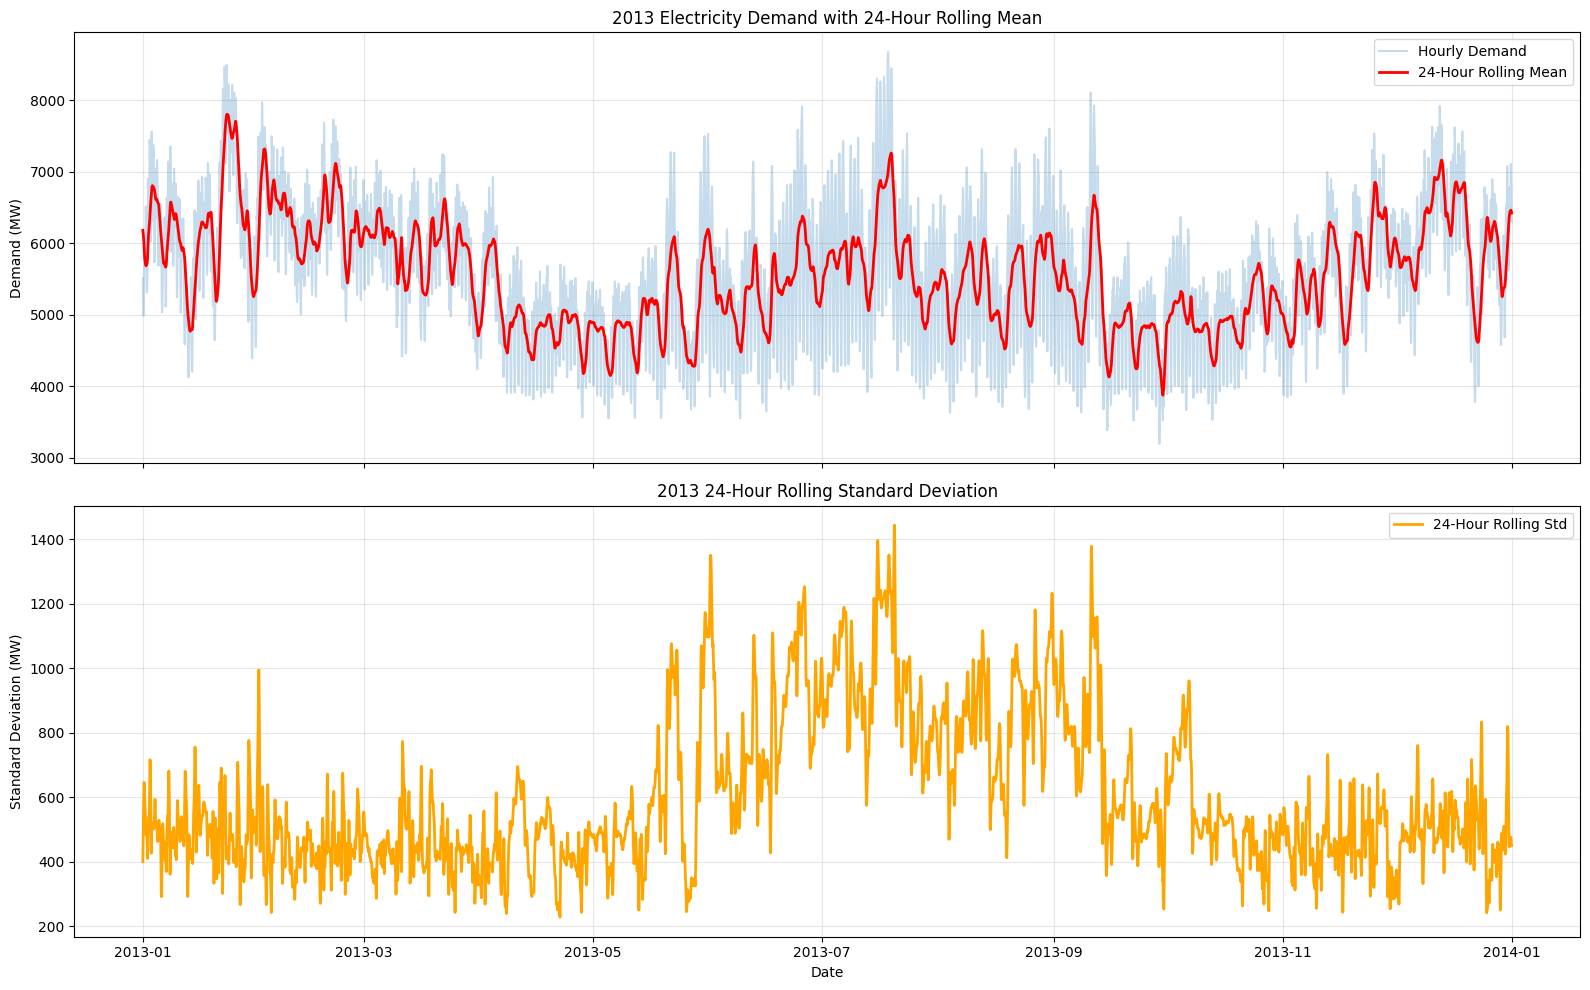

In [156]:
# 2013 - 24-HOUR ROLLING MEAN AND STANDARD DEVIATION

df_2013 = df[df["Year"] == 2013].copy()

fig, axes = plt.subplots(
    2, 1,
    figsize=(16, 10),
    sharex=True
)

# ------------------------------------------------------------
# Rolling Mean
# ------------------------------------------------------------

axes[0].plot(
    df_2013["Datetime"],
    df_2013["PJMW_MW_Clean"],
    alpha=0.25,
    label="Hourly Demand"
)

axes[0].plot(
    df_2013["Datetime"],
    df_2013["Rolling_Mean_24"],
    linewidth=2,
    color="red",
    label="24-Hour Rolling Mean"
)

axes[0].set_title(
    "2013 Electricity Demand with 24-Hour Rolling Mean"
)

axes[0].set_ylabel("Demand (MW)")
axes[0].legend()
axes[0].grid(alpha=0.3)


# ------------------------------------------------------------
# Rolling Standard Deviation
# ------------------------------------------------------------

axes[1].plot(
    df_2013["Datetime"],
    df_2013["Rolling_Std_24"],
    linewidth=2,
    color="orange",
    label="24-Hour Rolling Std"
)

axes[1].set_title(
    "2013 24-Hour Rolling Standard Deviation"
)

axes[1].set_xlabel("Date")
axes[1].set_ylabel("Standard Deviation (MW)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Final EDA summary table

In [157]:
# FINAL EDA SUMMARY

overall_mean = df["PJMW_MW_Clean"].mean()

summary = {
    "Total Observations": len(df),

    "Start Date": df["Datetime"].min(),

    "End Date": df["Datetime"].max(),

    "Average Demand (MW)": round(
        df["PJMW_MW_Clean"].mean(),
        2
    ),

    "Median Demand (MW)": round(
        df["PJMW_MW_Clean"].median(),
        2
    ),

    "Minimum Demand (MW)": round(
        df["PJMW_MW_Clean"].min(),
        2
    ),

    "Maximum Demand (MW)": round(
        df["PJMW_MW_Clean"].max(),
        2
    ),

    "Standard Deviation (MW)": round(
        df["PJMW_MW_Clean"].std(),
        2
    )
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

display(summary_df)

,Metric,Value
0,Total Observations,143206
1,Start Date,2002-04-01 01:00:00
2,End Date,2018-08-03 00:00:00
3,Average Demand (MW),5602.41
4,Median Demand (MW),5530.0
5,Minimum Demand (MW),2553.0
6,Maximum Demand (MW),9594.0
7,Standard Deviation (MW),979.05


PRINT BUSINESS FINDINGS

In [158]:
# BUSINESS INSIGHT NUMBERS

# Overall average
overall = df["PJMW_MW_Clean"].mean()

# Highest season
highest_season = (
    seasonal_demand["Mean"]
    .idxmax()
)

highest_season_value = (
    seasonal_demand["Mean"]
    .max()
)

# Lowest season
lowest_season = (
    seasonal_demand["Mean"]
    .idxmin()
)

lowest_season_value = (
    seasonal_demand["Mean"]
    .min()
)

# Peak hour
peak_hour = hourly_demand.idxmax()
peak_hour_value = hourly_demand.max()

# Lowest hour
low_hour = hourly_demand.idxmin()
low_hour_value = hourly_demand.min()

# Highest weekday
highest_day = daily_demand.idxmax()

In [159]:
day_of_week_average = (
    df
    .groupby("Day_Name")["PJMW_MW_Clean"]
    .mean()
    .reindex(day_order)
)

highest_day_name = (
    day_of_week_average.idxmax()
)

highest_day_value = (
    day_of_week_average.max()
)

lowest_day_name = (
    day_of_week_average.idxmin()
)

lowest_day_value = (
    day_of_week_average.min()
)

In [160]:
# PRINT BUSINESS FINDINGS

print("=" * 60)
print("BUSINESS INSIGHTS")
print("=" * 60)

print(
    f"\nOverall average demand: "
    f"{overall:,.2f} MW"
)

print(
    f"\nHighest-demand season: "
    f"{highest_season} "
    f"({highest_season_value:,.2f} MW)"
)

print(
    f"Lowest-demand season: "
    f"{lowest_season} "
    f"({lowest_season_value:,.2f} MW)"
)

print(
    f"\nPeak average hour: "
    f"{peak_hour}:00 "
    f"({peak_hour_value:,.2f} MW)"
)

print(
    f"Lowest average hour: "
    f"{low_hour}:00 "
    f"({low_hour_value:,.2f} MW)"
)

print(
    f"\nHighest-demand day of week: "
    f"{highest_day_name} "
    f"({highest_day_value:,.2f} MW)"
)

print(
    f"Lowest-demand day of week: "
    f"{lowest_day_name} "
    f"({lowest_day_value:,.2f} MW)"
)

print("=" * 60)

BUSINESS INSIGHTS

Overall average demand: 5,602.41 MW

Highest-demand season: Winter (6,268.81 MW)
Lowest-demand season: Fall (5,200.14 MW)

Peak average hour: 19:00 (6,199.29 MW)
Lowest average hour: 4:00 (4,672.54 MW)

Highest-demand day of week: Wednesday (5,802.37 MW)
Lowest-demand day of week: Sunday (5,149.64 MW)


EDA GRAPHS - Hour, Season , Day, Month 

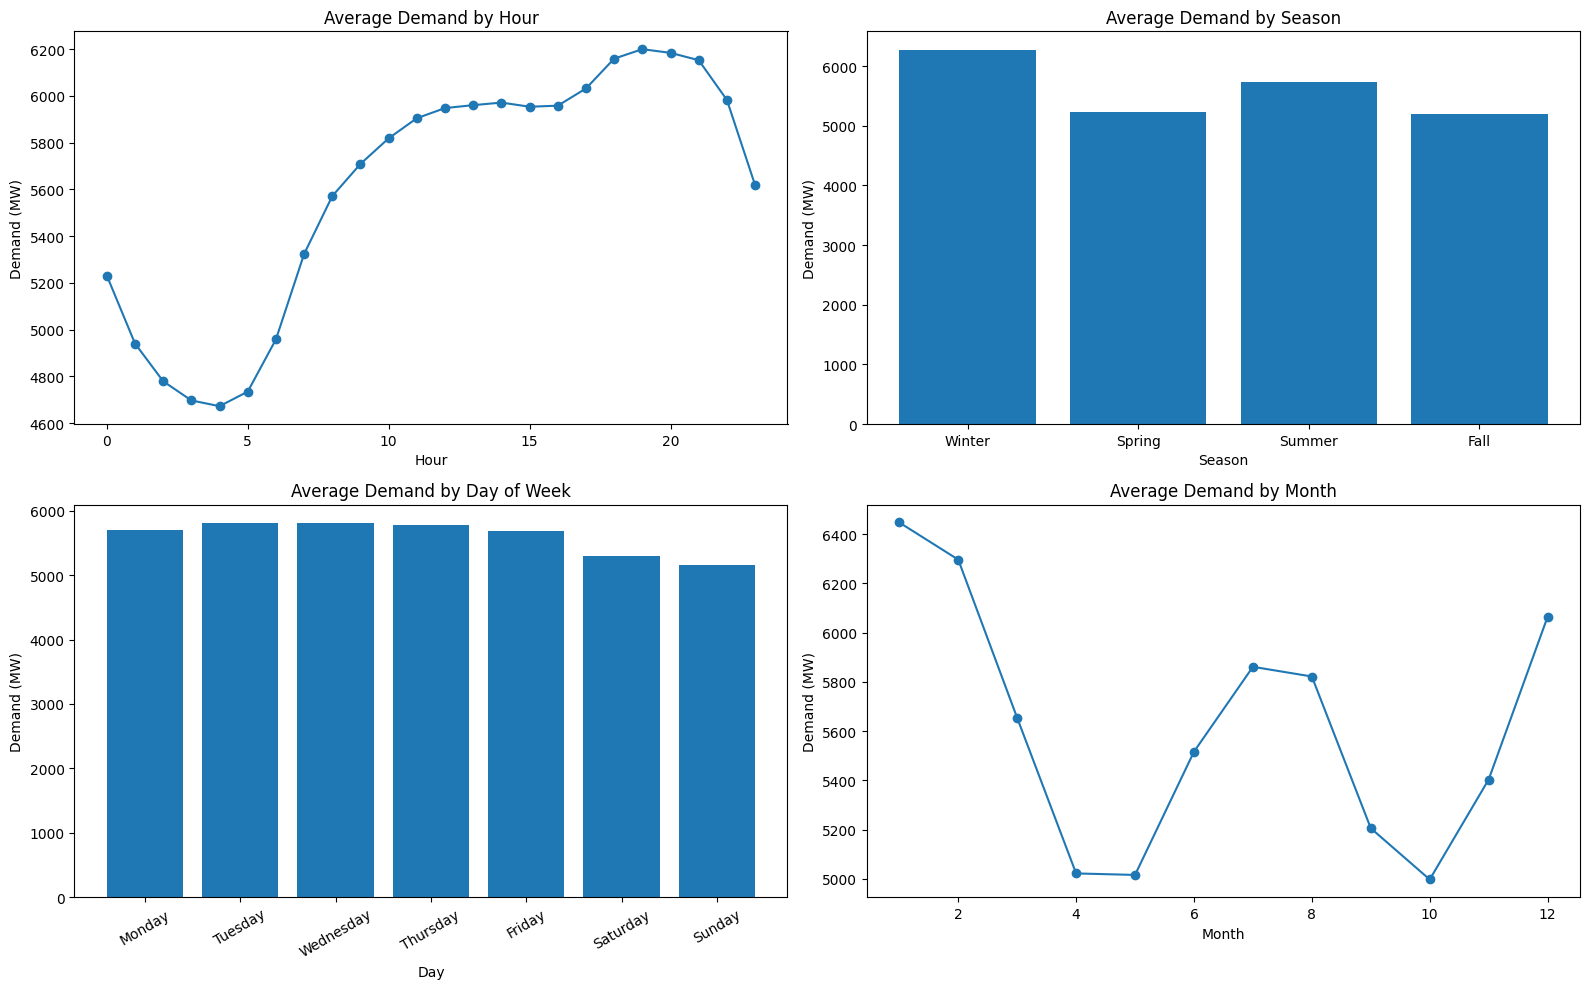

In [161]:
# MAIN EDA GRAPHS


fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 10)
)

# ------------------------------------------------------------
# Graph 1: Hourly
# ------------------------------------------------------------

axes[0, 0].plot(
    hourly_demand.index,
    hourly_demand.values,
    marker="o"
)

axes[0, 0].set_title(
    "Average Demand by Hour"
)

axes[0, 0].set_xlabel("Hour")
axes[0, 0].set_ylabel("Demand (MW)")


# ------------------------------------------------------------
# Graph 2: Season
# ------------------------------------------------------------

axes[0, 1].bar(
    seasonal_demand.index,
    seasonal_demand["Mean"]
)

axes[0, 1].set_title(
    "Average Demand by Season"
)

axes[0, 1].set_xlabel("Season")
axes[0, 1].set_ylabel("Demand (MW)")


# ------------------------------------------------------------
# Graph 3: Day of week
# ------------------------------------------------------------

axes[1, 0].bar(
    day_of_week_average.index,
    day_of_week_average.values
)

axes[1, 0].set_title(
    "Average Demand by Day of Week"
)

axes[1, 0].set_xlabel("Day")
axes[1, 0].set_ylabel("Demand (MW)")

axes[1, 0].tick_params(
    axis="x",
    rotation=30
)


# ------------------------------------------------------------
# Graph 4: Monthly
# ------------------------------------------------------------

axes[1, 1].plot(
    monthly_demand.index,
    monthly_demand.values,
    marker="o"
)

axes[1, 1].set_title(
    "Average Demand by Month"
)

axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Demand (MW)")


plt.tight_layout()
plt.show()

# Thank you !!!